# Probabilistic EDA — GB Day-Ahead Price Forecasting

Exploratory data analysis to inform feature selection for a LightGBM quantile regression model
forecasting the 48 half-hour GB day-ahead prices (D+1).

**Coverage**
1. Setup and imports
2. Load data
3. Data validation and cleaning
4. Feature engineering (`df_hh`, `df_day`)
5. Target distribution EDA
6. Calendar effect EDA
7. Lagged price dependence EDA
8. Fundamental driver EDA
9. Redundancy and feature screening
10. Rough feature importance (LightGBM)
11. Final summary and provisional feature shortlist

**No-leakage principle**: all features mimic what would be known *before* the D-1 gate-closure.

## 1 · Setup and Imports

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# ── Numeric / Data ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Plotting ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11})

# ── Stats ─────────────────────────────────────────────────────────────────────
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import mutual_info_regression
from sklearn.pipeline import make_pipeline

print("Imports OK")

Imports OK


In [2]:
# ── Configurable constants ────────────────────────────────────────────────────
# Notebook working directory MUST be project root: /Users/haowu/Projects/BESS

# ---- File paths ----
MIP_PATH         = Path("data/raw/mip/mip_2023-01-01_2026-03-01.parquet")
DEMAND_PATH      = Path("data/raw/demand/demand_2023-01-01_2026-03-01.parquet")
WIND_PATH        = Path("data/raw/wind/wind_2023-01-01_2026-03-01.parquet")
EMBEDDED_PATH    = Path("data/raw/embedded/embedded_da_2023-01-01_2026-03-01.parquet")
DRM_IC_PATH      = Path("data/processed/features_drm_interconnectors.parquet")

# ---- Price thresholds ----
NEGATIVE_THRESHOLD = 0     # £/MWh
SPIKE_THRESHOLD    = 200   # £/MWh

# ---- Settlement period windows ----
MORNING_SPS = list(range(14, 23))   # SPs 14–22 ≈ 07:00–11:00
EVENING_SPS = list(range(32, 43))   # SPs 32–42 ≈ 16:00–21:00
STANDARD_SPS = 48

# ---- Date range ----
START_DATE = "2023-01-01"
END_DATE   = "2026-03-01"

print(f"DRM_IC_PATH exists: {DRM_IC_PATH.exists()}")

DRM_IC_PATH exists: True


## 2 · Load Data

In [3]:
def load_and_cast(path: Path, date_col: str = "settlement_date") -> pd.DataFrame:
    """Load parquet, ensure date column is date type, sp is int."""
    df = pd.read_parquet(path)
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col]).dt.date
    if "settlement_period" in df.columns:
        df["settlement_period"] = df["settlement_period"].astype(int)
    return df


mip      = load_and_cast(MIP_PATH)
demand   = load_and_cast(DEMAND_PATH)
wind     = load_and_cast(WIND_PATH)
embedded = load_and_cast(EMBEDDED_PATH)

print("MIP     ", mip.shape,      list(mip.columns))
print("Demand  ", demand.shape,   list(demand.columns))
print("Wind    ", wind.shape,     list(wind.columns))
print("Embedded", embedded.shape, list(embedded.columns))

MIP      (55482, 4) ['settlement_date', 'settlement_period', 'price', 'volume']
Demand   (55488, 3) ['settlement_date', 'settlement_period', 'demand']
Wind     (55488, 3) ['settlement_date', 'settlement_period', 'wind_da']
Embedded (54960, 4) ['settlement_date', 'settlement_period', 'emb_solar', 'emb_wind']


In [4]:
# ── Merge all sources on (settlement_date, settlement_period) ─────────────────
KEY = ["settlement_date", "settlement_period"]

emb_extra_cols = [c for c in embedded.columns if c not in KEY]

panel = (
    mip[KEY + ["price"]]
    .merge(demand[KEY + ["demand"]], on=KEY, how="outer")
    .merge(wind[KEY + ["wind_da"]], on=KEY, how="left")
    .merge(embedded[KEY + emb_extra_cols], on=KEY, how="left")
)

# Net load: demand minus all renewable generation forecasts
panel["net_load"] = (
    panel["demand"]
    - panel["wind_da"].fillna(0)
    - (panel["emb_wind"].fillna(0) if "emb_wind" in panel.columns else 0)
    - (panel["emb_solar"].fillna(0) if "emb_solar" in panel.columns else 0)
)

panel = panel.sort_values(KEY).reset_index(drop=True)

print(f"Panel shape: {panel.shape}")
print(f"Date range: {panel.settlement_date.min()} → {panel.settlement_date.max()}")
panel

Panel shape: (55488, 8)
Date range: 2023-01-01 → 2026-03-01


,settlement_date,settlement_period,price,demand,wind_da,emb_solar,emb_wind,net_load
0,2023-01-01,1,62.48,21200.0,8479.0,NaN,NaN,12721.0
1,2023-01-01,2,103.42,21500.0,8699.0,NaN,NaN,12801.0
2,2023-01-01,3,122.10,21140.0,8857.0,NaN,NaN,12283.0
3,2023-01-01,4,52.75,20416.0,8952.0,NaN,NaN,11464.0
4,2023-01-01,5,33.50,19804.0,9030.0,NaN,NaN,10774.0
...,...,...,...,...,...,...,...,...
55483,2026-03-01,44,54.22,26208.0,19440.0,0.0,5121.0,1647.0
55484,2026-03-01,45,48.61,24732.0,19467.0,0.0,5144.0,121.0
55485,2026-03-01,46,35.70,23251.0,19459.0,0.0,5166.0,-1374.0
55486,2026-03-01,47,30.38,22011.0,19432.0,0.0,5163.0,-2584.0


In [5]:
# Load pre-built D-2 DRM and interconnector features.
# This file has one row per target_date; all values are D-2 actuals (no leakage).
# D-2 because at bid time (before 10:00 on D-1), only D-2 has a complete day of actuals.
drm_ic_df = pd.read_parquet(DRM_IC_PATH)
drm_ic_df["target_date"] = pd.to_datetime(drm_ic_df["target_date"]).dt.date
print(f"DRM/IC features shape: {drm_ic_df.shape}")
print(f"Date range: {drm_ic_df['target_date'].min()} → {drm_ic_df['target_date'].max()}")
drm_ic_df.head()

DRM/IC features shape: (1156, 20)
Date range: 2023-01-03 → 2026-03-03


,drm_mean,drm_min,lolp_max,drm_eve_mean,drm_roll7,target_date,ic_mean_britned,ic_mean_eleclink,ic_mean_ew_ireland,ic_mean_greenlink,ic_mean_ifa,ic_mean_ifa2,ic_mean_moyle,ic_mean_nemo,ic_mean_nsl,ic_mean_viking,ic_total_mean,ic_total_min,ic_total_max,ic_total_roll7
0,18576.551506,9964.6984,0.000000e+00,10863.235567,18576.551506,2023-01-03,282.416667,993.875000,-364.916667,NaN,913.708333,968.208333,-349.500000,582.458333,320.166667,NaN,3346.416667,-402,6138,3346.416667
1,15738.122901,8339.1552,0.000000e+00,9039.462973,17157.337204,2023-01-04,881.208333,995.750000,76.708333,NaN,713.625000,766.291667,-59.958333,897.208333,1116.375000,NaN,5387.208333,2376,7228,4366.812500
2,18179.705035,11303.2561,0.000000e+00,11875.885667,17498.126481,2023-01-05,621.791667,633.000000,17.875000,NaN,449.875000,418.416667,-4.833333,561.416667,315.416667,NaN,3012.958333,-1010,6256,3915.527778
3,20467.905556,13910.9850,0.000000e+00,14632.559533,18240.571250,2023-01-06,384.250000,649.708333,10.125000,NaN,432.958333,442.791667,-80.583333,533.083333,423.125000,NaN,2795.458333,-4112,5994,3635.510417
4,16047.574733,9427.1663,6.000000e-08,10655.373733,17801.971946,2023-01-07,403.750000,452.041667,-64.041667,NaN,526.500000,121.375000,-0.208333,391.750000,403.000000,NaN,2234.166667,-2292,6106,3355.241667


## 3 · Data Validation and Cleaning

In [6]:
# ── Duplicate (date, SP) check ────────────────────────────────────────────────
n_dupes = panel.duplicated(subset=KEY).sum()
print(f"Duplicate (date, SP) rows: {n_dupes}")
if n_dupes > 0:
    panel = panel.drop_duplicates(subset=KEY, keep="first")
    print("  → Dropped duplicates, kept first.")

Duplicate (date, SP) rows: 0


In [7]:
# ── Settlement period count per day ───────────────────────────────────────────
sp_counts = panel.groupby("settlement_date")["settlement_period"].count()
non_48 = sp_counts[sp_counts != STANDARD_SPS]
print(f"Days with SP count ≠ 48: {len(non_48)}")
if len(non_48) > 0:
    print(non_48.to_string())

# DST-affected dates — exclude from main EDA
dst_dates = set(non_48.index)
print(f"\nExcluding {len(dst_dates)} DST-affected dates from EDA.")

Days with SP count ≠ 48: 6
settlement_date
2023-03-26    46
2023-10-29    50
2024-03-31    46
2024-10-27    50
2025-03-30    46
2025-10-26    50

Excluding 6 DST-affected dates from EDA.


In [8]:
# ── Clean panel: exclude DST days, filter date range ─────────────────────────
panel_clean = panel[
    (~panel["settlement_date"].isin(dst_dates))
    & (panel["settlement_date"] >= pd.to_datetime(START_DATE).date())
    & (panel["settlement_date"] <= pd.to_datetime(END_DATE).date())
].copy()

print(f"Clean panel: {panel_clean.shape}  ({panel_clean.settlement_date.nunique()} days)")

Clean panel: (55200, 8)  (1150 days)


In [9]:
# ── Missingness by column ─────────────────────────────────────────────────────
miss = panel_clean.isnull().sum()
miss_pct = (miss / len(panel_clean) * 100).round(2)
miss_df = pd.DataFrame({"missing_n": miss, "missing_%": miss_pct})
print(miss_df[miss_df.missing_n > 0].to_string() or "No missing values")

           missing_n  missing_%
price              6       0.01
demand           527       0.95
emb_solar        576       1.04
emb_wind         576       1.04
net_load         527       0.95


In [10]:
# ── Missingness by month ──────────────────────────────────────────────────────
panel_clean["_ym"] = pd.to_datetime(panel_clean["settlement_date"]).dt.to_period("M")
miss_by_month = panel_clean.groupby("_ym")["price"].apply(lambda s: s.isnull().mean() * 100)
if miss_by_month.gt(0).any():
    print("Price missingness by month (%):\n", miss_by_month[miss_by_month > 0].to_string())
else:
    print("Price: no missingness by month.")
panel_clean.drop(columns=["_ym"], inplace=True)

Price missingness by month (%):
 _ym
2023-05    0.067204
2023-06    0.069444
2023-07    0.067204
2023-11    0.069444
2023-12    0.067204
2024-04    0.069444
Freq: M


In [11]:
# ── Numeric type check ────────────────────────────────────────────────────────
print(panel_clean.dtypes)

settlement_date       object
settlement_period      int64
price                float64
demand               float64
wind_da              float64
emb_solar            float64
emb_wind             float64
net_load             float64
dtype: object


### Missing data imputation

In [12]:
# ── Interpolate missing values in panel_clean ─────────────────────────────
# Use time-linear interpolation for price, demand, emb_solar, emb_wind, net_load.
# Gaps are typically short (DST transitions, brief data outages) so linear
# interpolation across settlement periods is appropriate.  Any leading /
# trailing NaNs that cannot be interpolated are back/forward-filled as a
# last resort.

INTERP_COLS = [c for c in ["price", "demand", "emb_solar", "emb_wind", "net_load"]
               if c in panel_clean.columns]

before = panel_clean[INTERP_COLS].isna().sum().rename("missing_before")

panel_clean = (
    panel_clean
    .sort_values(["settlement_date", "settlement_period"])
    .copy()
)
panel_clean[INTERP_COLS] = (
    panel_clean[INTERP_COLS]
    .interpolate(method="linear", limit_direction="both")
)

after = panel_clean[INTERP_COLS].isna().sum().rename("missing_after")

imputation_summary = pd.concat([before, after], axis=1)
imputation_summary["imputed"] = imputation_summary["missing_before"] - imputation_summary["missing_after"]
print(imputation_summary)

           missing_before  missing_after  imputed
price                   6              0        6
demand                527              0      527
emb_solar             576              0      576
emb_wind              576              0      576
net_load              527              0      527


## 4 · Feature Engineering

In [13]:
# ── Half-hourly feature table (df_hh) ─────────────────────────────────────────
df_hh = panel_clean.copy()

# ---- Calendar features ----
_dt = pd.to_datetime(df_hh["settlement_date"])
df_hh["weekday"]    = _dt.dt.weekday          # 0=Mon, 6=Sun
df_hh["is_weekend"] = (_dt.dt.weekday >= 5).astype(int)
df_hh["month"]      = _dt.dt.month
df_hh["quarter"]    = _dt.dt.quarter
df_hh["day_of_year"] = _dt.dt.dayofyear

# SP-based hour (each SP = 30 min, SP 1 starts at 00:00)
df_hh["hour"] = ((df_hh["settlement_period"] - 1) * 0.5).astype(float)

# Cyclical encodings
df_hh["sp_sin"]  = np.sin(2 * np.pi * df_hh["settlement_period"] / 48)
df_hh["sp_cos"]  = np.cos(2 * np.pi * df_hh["settlement_period"] / 48)
df_hh["doy_sin"] = np.sin(2 * np.pi * df_hh["day_of_year"] / 365)
df_hh["doy_cos"] = np.cos(2 * np.pi * df_hh["day_of_year"] / 365)

print("Calendar features added.")

Calendar features added.


In [14]:
# ── Lagged same-period price features ─────────────────────────────────────────
# Sort by SP then date so shifting by N rows = N days for same SP
df_hh = df_hh.sort_values(["settlement_period", "settlement_date"]).reset_index(drop=True)

def add_sp_lags(df, col="price", lags=[1, 2, 7]):
    """Add lag features within each settlement period group."""
    df = df.copy()
    for lag in lags:
        df[f"{col}_lag{lag}d"] = df.groupby("settlement_period")[col].shift(lag)
    # Rolling 3d and 7d stats (same period, previous days)
    for window in [3, 7]:
        roll = df.groupby("settlement_period")[col].transform(
            lambda s: s.shift(1).rolling(window, min_periods=2).mean()
        )
        df[f"{col}_roll{window}d_mean"] = roll
        roll_std = df.groupby("settlement_period")[col].transform(
            lambda s: s.shift(1).rolling(window, min_periods=2).std()
        )
        df[f"{col}_roll{window}d_std"] = roll_std
    return df

df_hh = add_sp_lags(df_hh, col="price", lags=[1, 2, 7])
print("Lag features added. Shape:", df_hh.shape)

Lag features added. Shape: (55200, 25)


In [15]:
# ── Merge D-2 DRM / LoLP and interconnector features onto df_hh ───────────────
# drm_ic_df has one row per target_date with all D-2 features pre-computed.
# Join on settlement_date == target_date so every half-hour row on day D
# carries the same D-2 capacity and flow signals.
df_hh = df_hh.merge(
    drm_ic_df.rename(columns={"target_date": "settlement_date"}),
    on="settlement_date",
    how="left",
)
drm_ic_cols = [c for c in drm_ic_df.columns if c != "target_date"]
print(f"Added DRM/IC features: {drm_ic_cols}")
print(f"df_hh shape after merge: {df_hh.shape}")

Added DRM/IC features: ['drm_mean', 'drm_min', 'lolp_max', 'drm_eve_mean', 'drm_roll7', 'ic_mean_britned', 'ic_mean_eleclink', 'ic_mean_ew_ireland', 'ic_mean_greenlink', 'ic_mean_ifa', 'ic_mean_ifa2', 'ic_mean_moyle', 'ic_mean_nemo', 'ic_mean_nsl', 'ic_mean_viking', 'ic_total_mean', 'ic_total_min', 'ic_total_max', 'ic_total_roll7']
df_hh shape after merge: (55200, 44)


In [16]:
# Re-sort by date, SP for downstream use
df_hh = df_hh.sort_values(KEY).reset_index(drop=True)
print(f"df_hh shape: {df_hh.shape}")
df_hh

df_hh shape: (55200, 44)


,settlement_date,settlement_period,price,demand,wind_da,emb_solar,emb_wind,net_load,weekday,is_weekend,...,ic_mean_ifa,ic_mean_ifa2,ic_mean_moyle,ic_mean_nemo,ic_mean_nsl,ic_mean_viking,ic_total_mean,ic_total_min,ic_total_max,ic_total_roll7
0,2023-01-01,1,62.48,21200.0,8479.0,0.0,864.0,12721.0,6,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-01-01,2,103.42,21500.0,8699.0,0.0,864.0,12801.0,6,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-01-01,3,122.10,21140.0,8857.0,0.0,864.0,12283.0,6,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-01-01,4,52.75,20416.0,8952.0,0.0,864.0,11464.0,6,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-01-01,5,33.50,19804.0,9030.0,0.0,864.0,10774.0,6,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55195,2026-03-01,44,54.22,26208.0,19440.0,0.0,5121.0,1647.0,6,1,...,1502.0,992.0,-424.75,999.541667,385.166667,719.583333,5003.833333,3384.0,6464.0,2995.767857
55196,2026-03-01,45,48.61,24732.0,19467.0,0.0,5144.0,121.0,6,1,...,1502.0,992.0,-424.75,999.541667,385.166667,719.583333,5003.833333,3384.0,6464.0,2995.767857
55197,2026-03-01,46,35.70,23251.0,19459.0,0.0,5166.0,-1374.0,6,1,...,1502.0,992.0,-424.75,999.541667,385.166667,719.583333,5003.833333,3384.0,6464.0,2995.767857
55198,2026-03-01,47,30.38,22011.0,19432.0,0.0,5163.0,-2584.0,6,1,...,1502.0,992.0,-424.75,999.541667,385.166667,719.583333,5003.833333,3384.0,6464.0,2995.767857


In [17]:
# ── Daily summary table (df_day) ──────────────────────────────────────────────
# Group on pd.to_datetime(...) so df_day gets a proper DatetimeIndex (Timestamps),
# not an object Index of datetime.date objects.
grp = df_hh.groupby(pd.to_datetime(df_hh["settlement_date"]))

df_day = pd.DataFrame(
    index=pd.to_datetime(sorted(df_hh["settlement_date"].unique()))
)
df_day.index.name = "settlement_date"

# ---- Price target diagnostics ----
df_day["price_mean"]   = grp["price"].mean()
df_day["price_min"]    = grp["price"].min()
df_day["price_max"]    = grp["price"].max()
df_day["price_spread"] = df_day["price_max"] - df_day["price_min"]
df_day["price_std"]    = grp["price"].std()
df_day["price_neg_count"]   = grp["price"].apply(lambda s: (s < NEGATIVE_THRESHOLD).sum())
df_day["price_spike_count"] = grp["price"].apply(lambda s: (s > SPIKE_THRESHOLD).sum())
# Average absolute half-hour change
df_day["price_abs_hh_change"] = grp["price"].apply(lambda s: s.diff().abs().mean())
# Timing of max/min SP
df_day["sp_of_max"] = grp.apply(lambda g: g.loc[g["price"].idxmax(), "settlement_period"] if g["price"].notna().any() else np.nan)
df_day["sp_of_min"] = grp.apply(lambda g: g.loc[g["price"].idxmin(), "settlement_period"] if g["price"].notna().any() else np.nan)

# ---- Calendar ----
df_day["weekday"]    = df_day.index.weekday
df_day["is_weekend"] = (df_day.index.weekday >= 5).astype(int)
df_day["month"]      = df_day.index.month
df_day["quarter"]    = df_day.index.quarter

# ---- Lagged daily price stats ----
# df_day is already sorted (DatetimeIndex, sorted above) so shift/rolling are date-correct
for col in ["price_spread", "price_std", "price_neg_count", "price_spike_count"]:
    df_day[f"{col}_lag1d"] = df_day[col].shift(1)
for col in ["price_spread", "price_std"]:
    df_day[f"{col}_roll3d"] = df_day[col].shift(1).rolling(3, min_periods=2).mean()
    df_day[f"{col}_roll7d"] = df_day[col].shift(1).rolling(7, min_periods=4).mean()

# ---- Fundamental summaries ----
df_day["nl_mean"]   = grp["net_load"].mean()
df_day["nl_max"]    = grp["net_load"].max()
df_day["nl_min"]    = grp["net_load"].min()
df_day["nl_spread"] = df_day["nl_max"] - df_day["nl_min"]
df_day["nl_peak_sp"] = grp.apply(lambda g: g.loc[g["net_load"].idxmax(), "settlement_period"] if g["net_load"].notna().any() else np.nan)
df_day["nl_morning_avg"] = grp.apply(lambda g: g[g["settlement_period"].isin(MORNING_SPS)]["net_load"].mean())
df_day["nl_evening_avg"] = grp.apply(lambda g: g[g["settlement_period"].isin(EVENING_SPS)]["net_load"].mean())

df_day["demand_mean"] = grp["demand"].mean()
df_day["wind_mean"]   = grp["wind_da"].mean()
if "emb_solar" in df_hh.columns:
    df_day["emb_solar_mean"] = grp["emb_solar"].mean()
if "emb_wind" in df_hh.columns:
    df_day["emb_wind_mean"] = grp["emb_wind"].mean()

# ---- Evening price stats ----
df_day["price_evening_p75"] = grp.apply(
    lambda g: g[g["settlement_period"].isin(EVENING_SPS)]["price"].quantile(0.75)
)

print(f"df_day shape: {df_day.shape}")
print(f"df_day index dtype: {df_day.index.dtype}")
df_day.head(3)

df_day shape: (1150, 34)
df_day index dtype: datetime64[s]


,price_mean,price_min,price_max,price_spread,price_std,price_neg_count,price_spike_count,price_abs_hh_change,sp_of_max,sp_of_min,...,nl_min,nl_spread,nl_peak_sp,nl_morning_avg,nl_evening_avg,demand_mean,wind_mean,emb_solar_mean,emb_wind_mean,price_evening_p75
settlement_date,,,,,,,,,,,,,,,,,,,,,
2023-01-01,112.678542,-31.60,220.55,252.15,85.517189,10,7,13.990000,36,8,...,8548.0,17139.0,35,12372.555556,23707.181818,24490.125000,8123.979167,0.000000,864.000000,219.44
2023-01-02,125.764583,25.60,215.98,190.38,47.139440,0,4,15.390638,37,10,...,14577.0,18398.0,35,21175.333333,30528.000000,27107.729167,3167.520833,618.833333,967.854167,205.12
2023-01-03,142.106458,18.45,180.15,161.70,31.581076,0,0,17.054043,18,48,...,4873.0,19749.0,35,16615.666667,21559.090909,29647.958333,10246.916667,134.791667,2836.145833,166.57


In [18]:
# ── Merge D-2 DRM / IC features onto df_day ───────────────────────────────────
# df_day has a DatetimeIndex; drm_ic_df.target_date may be date objects, so
# convert to Timestamp before joining on the index.
_drm = (
    drm_ic_df
    .rename(columns={"target_date": "settlement_date"})
    .assign(settlement_date=lambda x: pd.to_datetime(x["settlement_date"]))
    .set_index("settlement_date")
)
df_day = df_day.merge(_drm, left_index=True, right_index=True, how="left")
print(f"Added DRM/IC features to df_day. Shape: {df_day.shape}")

Added DRM/IC features to df_day. Shape: (1150, 53)


## 5 · Target Distribution EDA

In [19]:
# ── Summary statistics table ───────────────────────────────────────────────────
p = df_hh["price"].dropna()
quantiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
stats_dict = {
    "mean": p.mean(), "median": p.median(), "std": p.std(),
    "skew": p.skew(), "kurtosis": p.kurtosis(),
    "min": p.min(), "max": p.max(),
}
stats_dict.update({f"P{int(q*100)}": p.quantile(q) for q in quantiles})
stats_df = pd.Series(stats_dict).rename("price (£/MWh)").to_frame()
print("=== Price Distribution Summary ===")
print(stats_df.round(2).to_string())
print(f"\nNegative price fraction : {(p < NEGATIVE_THRESHOLD).mean()*100:.2f}%")
print(f"Spike price fraction    : {(p > SPIKE_THRESHOLD).mean()*100:.2f}%")

=== Price Distribution Summary ===
          price (£/MWh)
mean              81.98
median            82.08
std               38.02
skew               3.49
kurtosis          94.76
min             -102.92
max             1352.90
P1                -9.80
P5                12.82
P10               40.32
P25               67.06
P50               82.08
P75               98.99
P90              120.32
P95              137.90
P99              179.23

Negative price fraction : 2.52%
Spike price fraction    : 0.46%


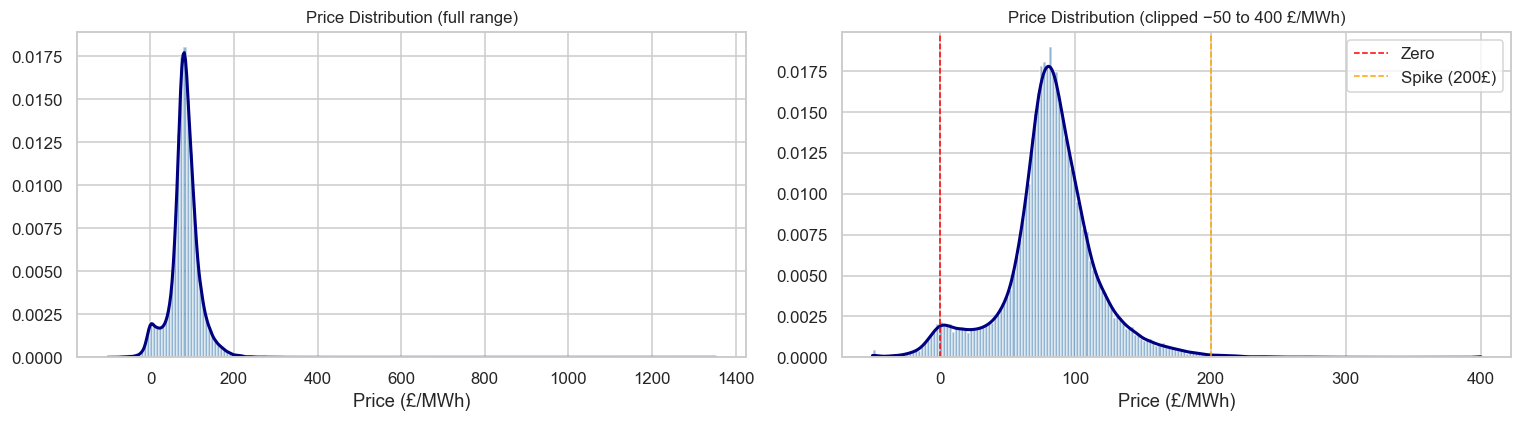

In [20]:
# ── Histogram + KDE ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full range
axes[0].hist(p, bins=200, density=True, alpha=0.6, color="steelblue", label="Full range")
from scipy.stats import gaussian_kde
kde = gaussian_kde(p.dropna())
xr = np.linspace(p.min(), p.max(), 500)
axes[0].plot(xr, kde(xr), color="navy", lw=2)
axes[0].set_title("Price Distribution (full range)")
axes[0].set_xlabel("Price (£/MWh)")

# Clipped to [-50, 400] for readability
p_clip = p.clip(-50, 400)
axes[1].hist(p_clip, bins=200, density=True, alpha=0.6, color="steelblue")
kde2 = gaussian_kde(p_clip)
xr2 = np.linspace(-50, 400, 500)
axes[1].plot(xr2, kde2(xr2), color="navy", lw=2)
axes[1].axvline(0, color="red", ls="--", lw=1, label="Zero")
axes[1].axvline(SPIKE_THRESHOLD, color="orange", ls="--", lw=1, label=f"Spike ({SPIKE_THRESHOLD}£)")
axes[1].set_title("Price Distribution (clipped −50 to 400 £/MWh)")
axes[1].set_xlabel("Price (£/MWh)")
axes[1].legend()

plt.tight_layout()
plt.show()

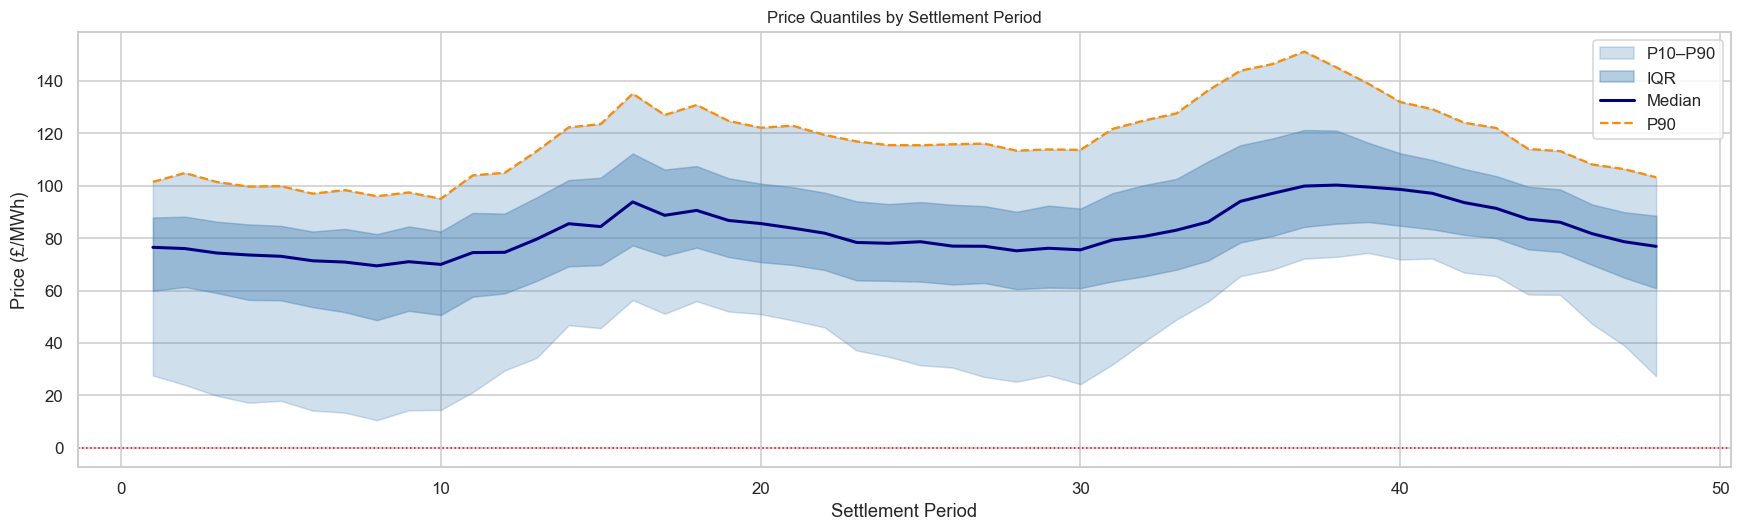

In [21]:
# ── Violin by settlement period ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
sp_sample = df_hh[["settlement_period", "price"]].dropna()
# Summarise per SP for cleaner violin
sp_stats = sp_sample.groupby("settlement_period")["price"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
ax.fill_between(sp_stats.index, sp_stats["10%"], sp_stats["90%"], alpha=0.25, color="steelblue", label="P10–P90")
ax.fill_between(sp_stats.index, sp_stats["25%"], sp_stats["75%"], alpha=0.4, color="steelblue", label="IQR")
ax.plot(sp_stats.index, sp_stats["50%"], color="navy", lw=2, label="Median")
ax.plot(sp_stats.index, sp_stats["90%"], color="darkorange", lw=1.5, ls="--", label="P90")
ax.axhline(0, color="red", ls=":", lw=1)
ax.set_xlabel("Settlement Period")
ax.set_ylabel("Price (£/MWh)")
ax.set_title("Price Quantiles by Settlement Period")
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
# ── Table: median, IQR, P90, P95 by SP ────────────────────────────────────────
sp_tbl = df_hh.groupby("settlement_period")["price"].agg(
    median="median",
    IQR=lambda s: s.quantile(0.75) - s.quantile(0.25),
    P90=lambda s: s.quantile(0.90),
    P95=lambda s: s.quantile(0.95),
    neg_pct=lambda s: (s < NEGATIVE_THRESHOLD).mean() * 100,
    spike_pct=lambda s: (s > SPIKE_THRESHOLD).mean() * 100,
).round(2)
print("=== Price stats by SP ===")
print(sp_tbl.to_string())

=== Price stats by SP ===
                   median    IQR     P90     P95  neg_pct  spike_pct
settlement_period                                                   
1                   76.50  27.97  101.49  113.55     2.52       0.00
2                   76.02  26.86  104.88  118.54     2.26       0.00
3                   74.32  27.25  101.45  115.82     2.43       0.00
4                   73.56  28.82   99.68  113.00     3.57       0.00
5                   73.07  28.44   99.88  110.19     3.39       0.00
6                   71.35  28.88   96.99  108.22     4.52       0.00
7                   70.86  31.79   98.36  109.62     4.70       0.00
8                   69.42  32.88   96.02  107.04     5.04       0.00
9                   71.00  32.22   97.46  111.10     4.52       0.00
10                  69.97  31.89   95.04  105.59     5.04       0.00
11                  74.48  31.99  103.97  122.02     3.91       0.00
12                  74.59  30.48  104.98  118.58     3.48       0.00
13      

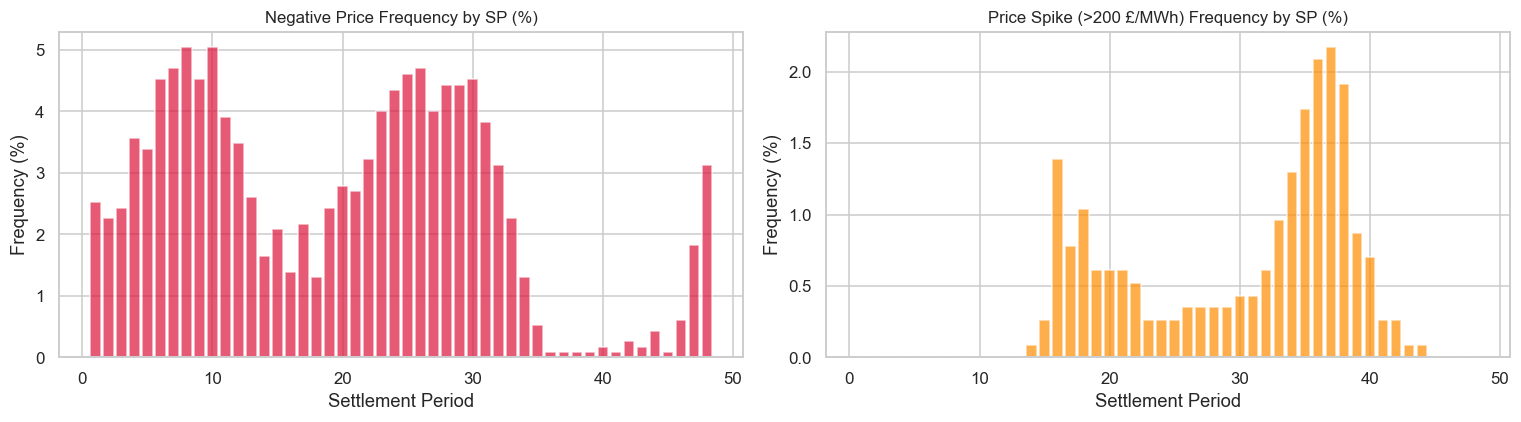

In [23]:
# ── Negative-price and spike frequency by SP ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(sp_tbl.index, sp_tbl["neg_pct"], color="crimson", alpha=0.7)
axes[0].set_title("Negative Price Frequency by SP (%)")
axes[0].set_xlabel("Settlement Period")
axes[0].set_ylabel("Frequency (%)")

axes[1].bar(sp_tbl.index, sp_tbl["spike_pct"], color="darkorange", alpha=0.7)
axes[1].set_title(f"Price Spike (>{SPIKE_THRESHOLD} £/MWh) Frequency by SP (%)")
axes[1].set_xlabel("Settlement Period")
axes[1].set_ylabel("Frequency (%)")

plt.tight_layout()
plt.show()

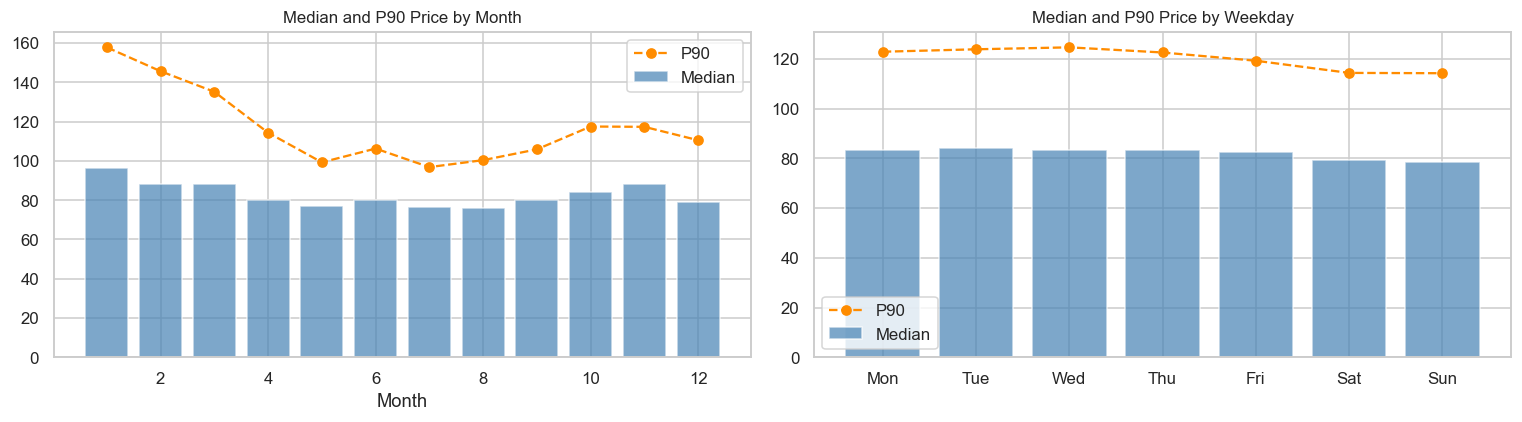

In [24]:
# ── Median + P90 by month and weekday ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

month_stats = df_hh.groupby("month")["price"].agg(median="median", P90=lambda s: s.quantile(0.9))
axes[0].bar(month_stats.index, month_stats["median"], color="steelblue", alpha=0.7, label="Median")
axes[0].plot(month_stats.index, month_stats["P90"], "o--", color="darkorange", label="P90")
axes[0].set_title("Median and P90 Price by Month")
axes[0].set_xlabel("Month")
axes[0].legend()

wd_stats = df_hh.groupby("weekday")["price"].agg(median="median", P90=lambda s: s.quantile(0.9))
wd_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
axes[1].bar(wd_stats.index, wd_stats["median"], color="steelblue", alpha=0.7, label="Median")
axes[1].plot(wd_stats.index, wd_stats["P90"], "o--", color="darkorange", label="P90")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(wd_names)
axes[1].set_title("Median and P90 Price by Weekday")
axes[1].legend()

plt.tight_layout()
plt.show()

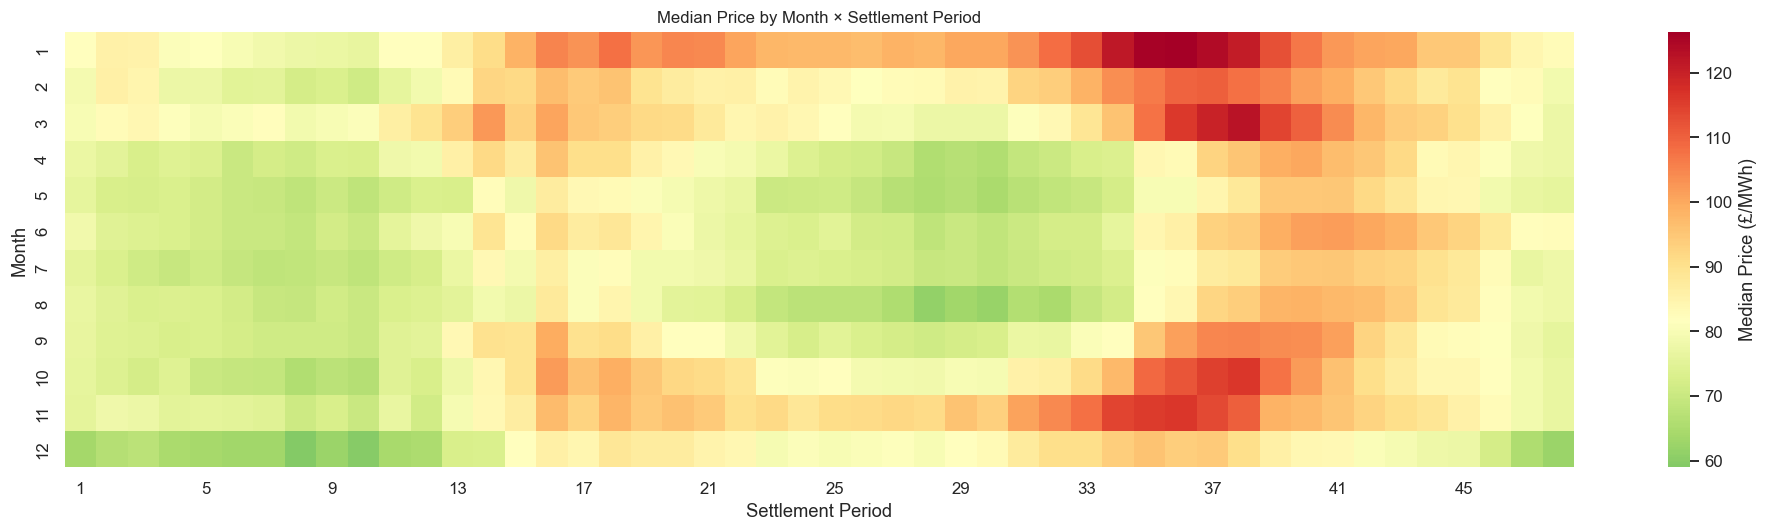

In [25]:
# ── Heatmap: median price by (month, SP) ──────────────────────────────────────
heat = df_hh.groupby(["month", "settlement_period"])["price"].median().unstack("settlement_period")
fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(
    heat, ax=ax, cmap="RdYlGn_r", center=heat.stack().median(),
    xticklabels=4, yticklabels=True, cbar_kws={"label": "Median Price (£/MWh)"}
)
ax.set_title("Median Price by Month × Settlement Period")
ax.set_xlabel("Settlement Period")
ax.set_ylabel("Month")
plt.tight_layout()
plt.show()

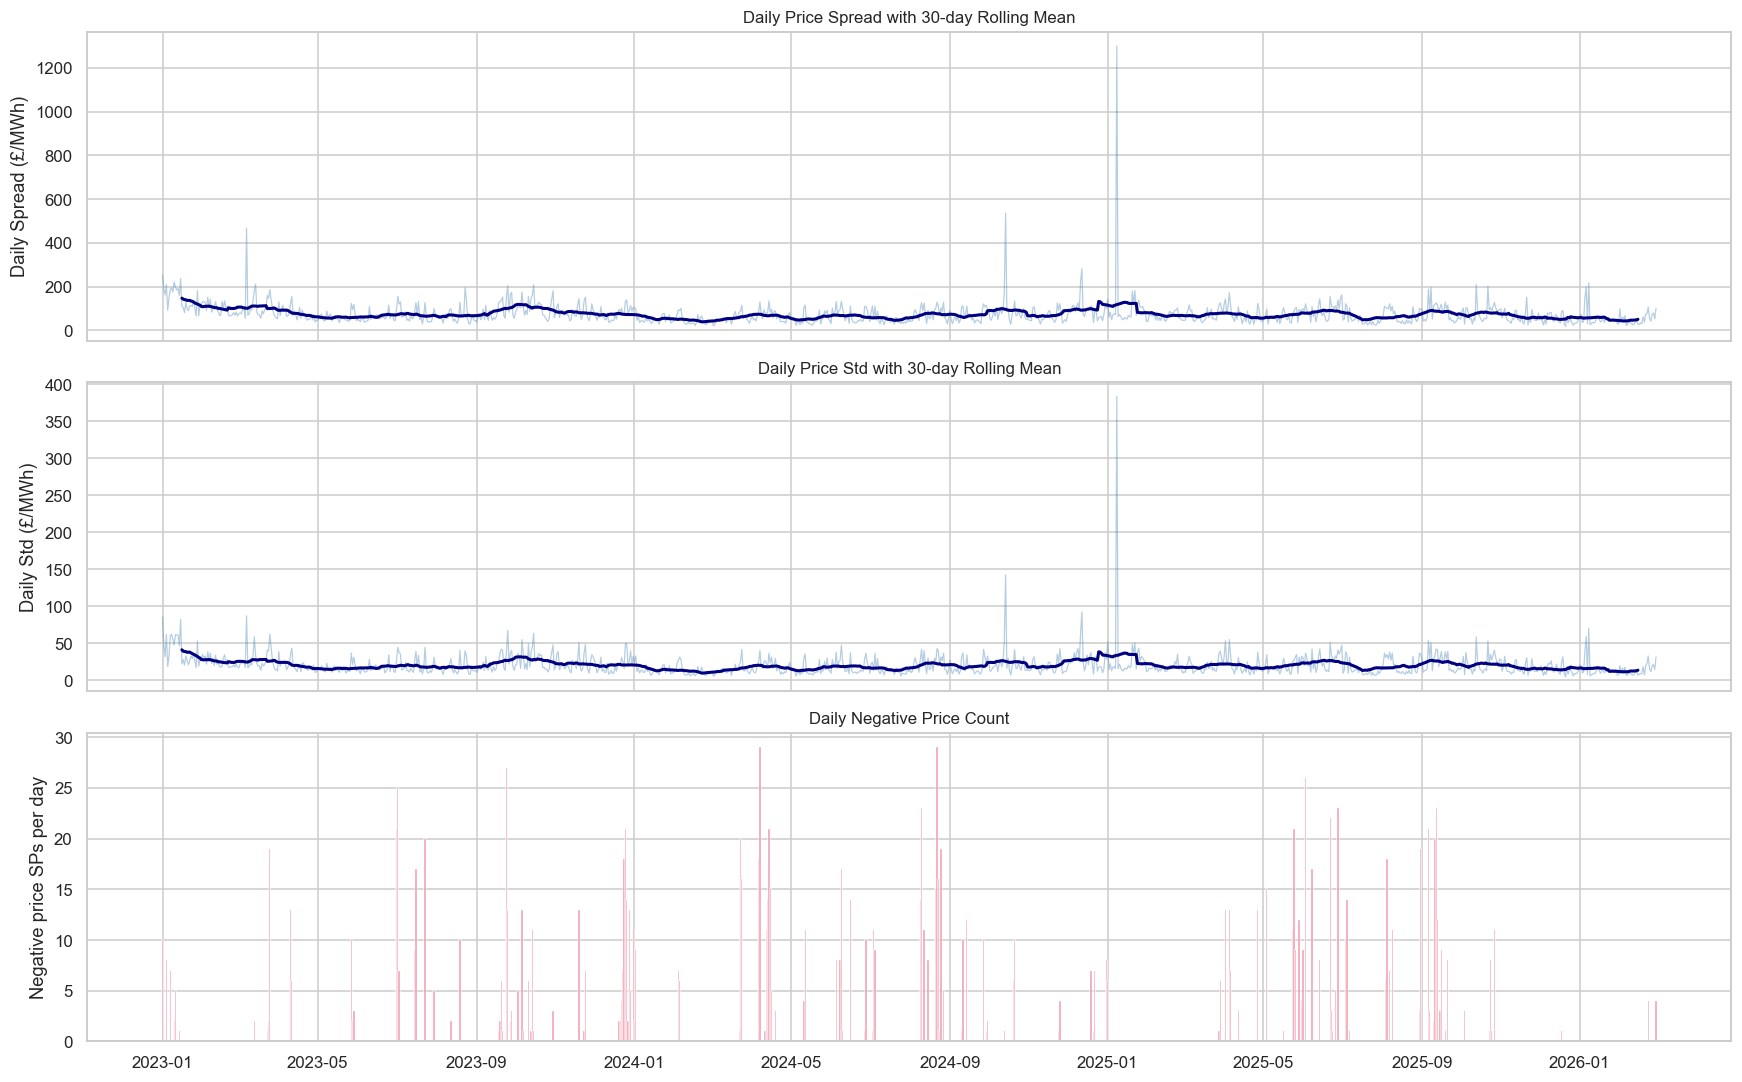

In [26]:
# ── Daily spread/std time series + rolling mean ────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

_dates = pd.to_datetime(df_day.index)
axes[0].plot(_dates, df_day["price_spread"], alpha=0.4, color="steelblue", lw=0.8)
axes[0].plot(_dates, df_day["price_spread"].rolling(30, center=True).mean(), color="navy", lw=2)
axes[0].set_ylabel("Daily Spread (£/MWh)")
axes[0].set_title("Daily Price Spread with 30-day Rolling Mean")

axes[1].plot(_dates, df_day["price_std"], alpha=0.4, color="steelblue", lw=0.8)
axes[1].plot(_dates, df_day["price_std"].rolling(30, center=True).mean(), color="navy", lw=2)
axes[1].set_ylabel("Daily Std (£/MWh)")
axes[1].set_title("Daily Price Std with 30-day Rolling Mean")

axes[2].bar(_dates, df_day["price_neg_count"], color="crimson", alpha=0.6, width=1)
axes[2].set_ylabel("Negative price SPs per day")
axes[2].set_title("Daily Negative Price Count")

plt.tight_layout()
plt.show()

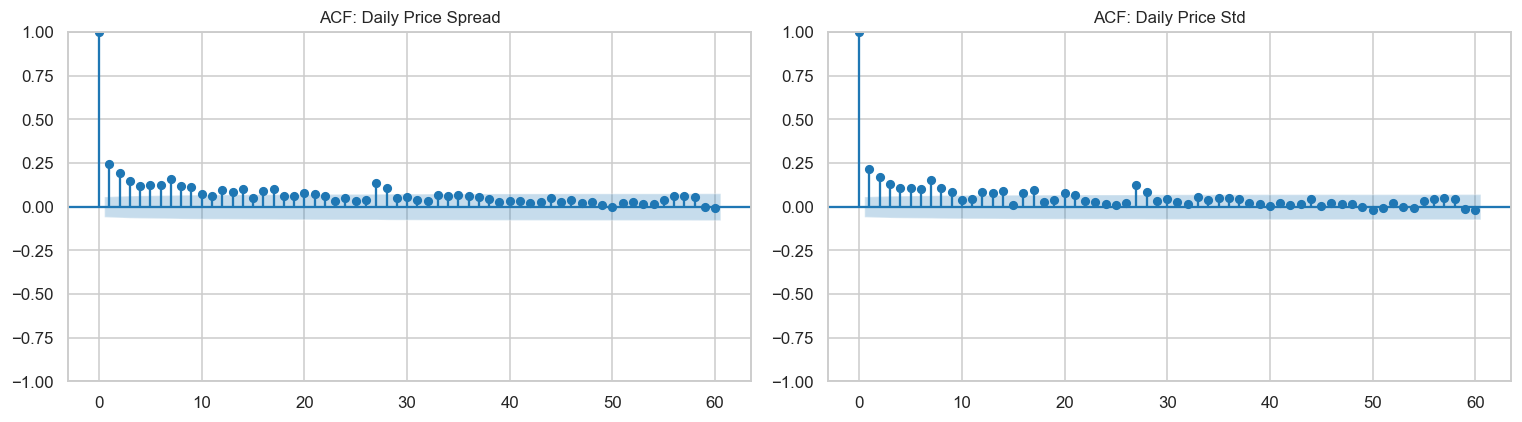

In [27]:
# ── ACF of daily spread and std ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df_day["price_spread"].dropna(), lags=60, ax=axes[0], title="ACF: Daily Price Spread")
plot_acf(df_day["price_std"].dropna(), lags=60, ax=axes[1], title="ACF: Daily Price Std")
plt.tight_layout()
plt.show()

## 6 · Calendar Effect EDA

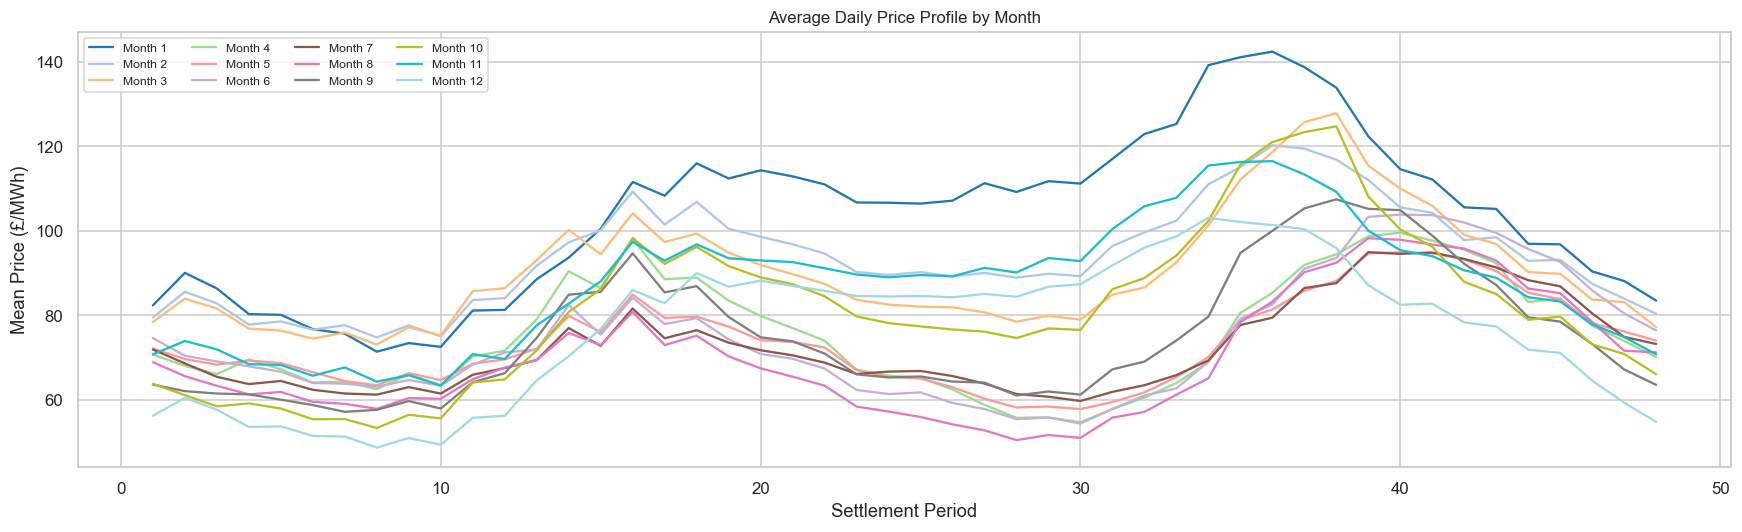

In [28]:
# ── Average daily price profile by month ──────────────────────────────────────
month_profile = df_hh.groupby(["month", "settlement_period"])["price"].mean().unstack("settlement_period")
fig, ax = plt.subplots(figsize=(16, 5))
cmap = plt.cm.get_cmap("tab20", 12)
for m in range(1, 13):
    if m in month_profile.index:
        ax.plot(month_profile.columns, month_profile.loc[m], label=f"Month {m}", color=cmap(m-1), lw=1.5)
ax.set_xlabel("Settlement Period")
ax.set_ylabel("Mean Price (£/MWh)")
ax.set_title("Average Daily Price Profile by Month")
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

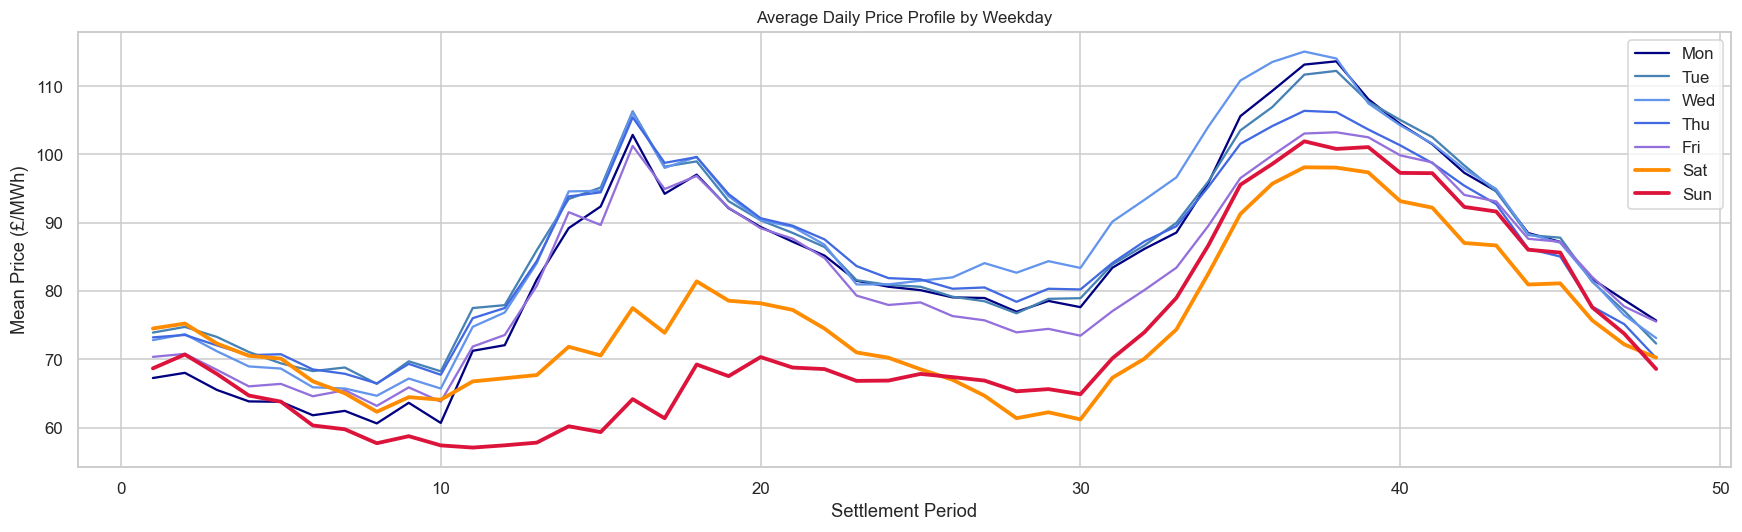

In [29]:
# ── Average daily profile by weekday ──────────────────────────────────────────
wd_profile = df_hh.groupby(["weekday", "settlement_period"])["price"].mean().unstack("settlement_period")
fig, ax = plt.subplots(figsize=(16, 5))
wd_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
colors = ["navy", "steelblue", "cornflowerblue", "royalblue", "mediumpurple", "darkorange", "crimson"]
for wd in range(7):
    if wd in wd_profile.index:
        lw = 2.5 if wd >= 5 else 1.5
        ax.plot(wd_profile.columns, wd_profile.loc[wd], label=wd_names[wd], color=colors[wd], lw=lw)
ax.set_xlabel("Settlement Period")
ax.set_ylabel("Mean Price (£/MWh)")
ax.set_title("Average Daily Price Profile by Weekday")
ax.legend()
plt.tight_layout()
plt.show()

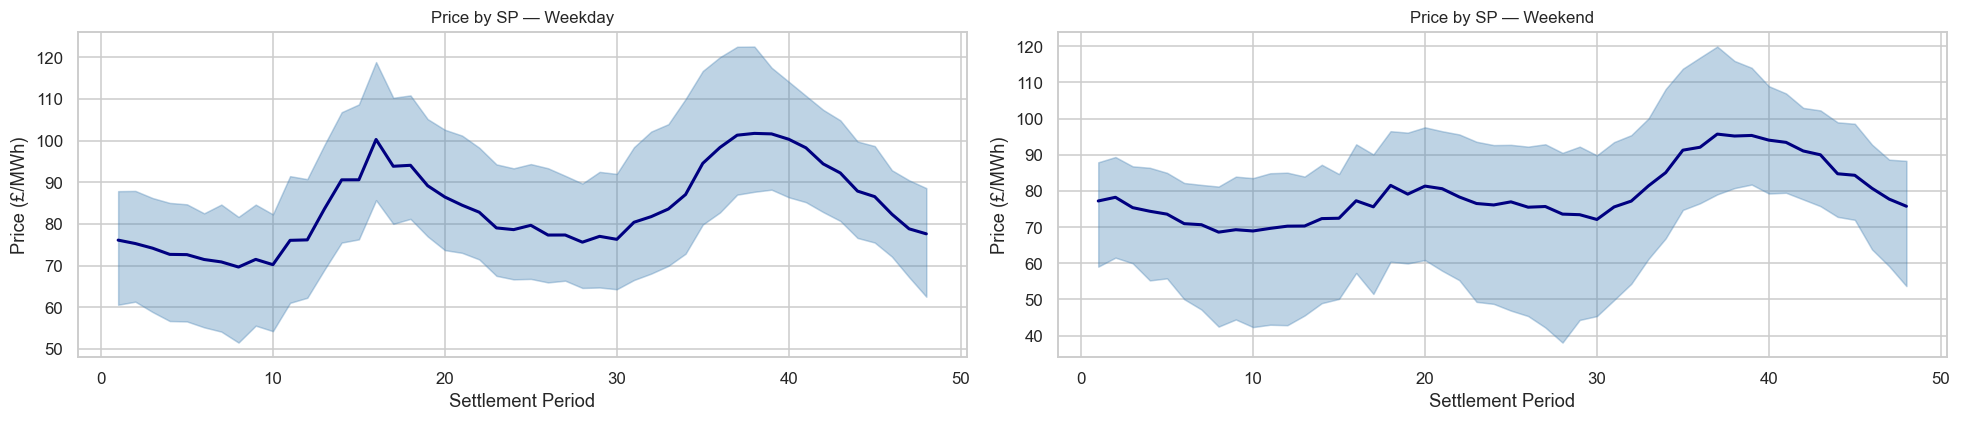

In [30]:
# ── Boxplots by SP split weekday vs weekend ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 4))
for ax, (label, mask) in zip(axes, [("Weekday", df_hh.is_weekend == 0), ("Weekend", df_hh.is_weekend == 1)]):
    sub = df_hh[mask].groupby("settlement_period")["price"].describe(percentiles=[0.25, 0.5, 0.75])
    ax.fill_between(sub.index, sub["25%"], sub["75%"], alpha=0.35, color="steelblue")
    ax.plot(sub.index, sub["50%"], color="navy", lw=2)
    ax.set_title(f"Price by SP — {label}")
    ax.set_xlabel("Settlement Period")
    ax.set_ylabel("Price (£/MWh)")
plt.tight_layout()
plt.show()

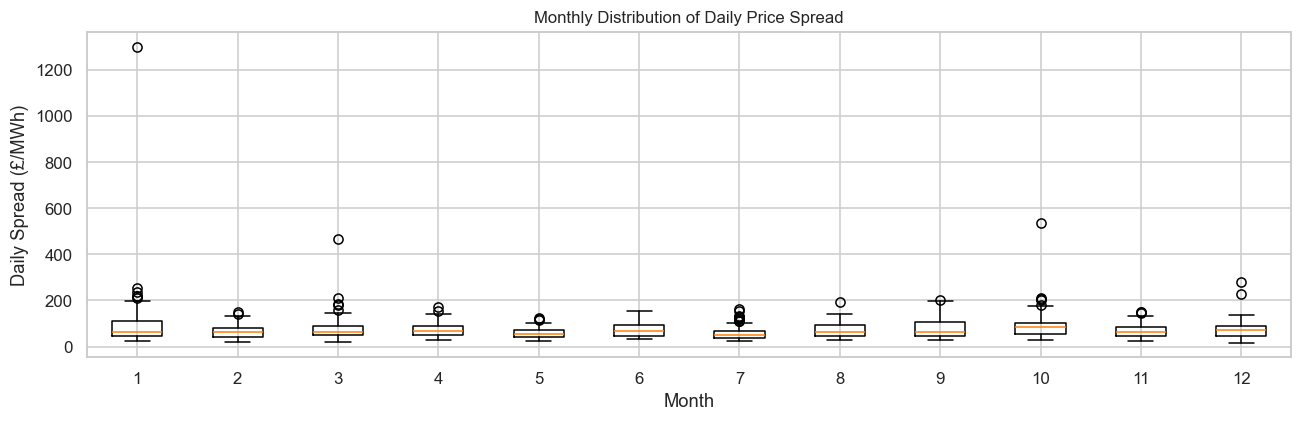

In [31]:
# ── Monthly boxplots of daily spread ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
groups = [df_day[df_day.month == m]["price_spread"].dropna() for m in range(1, 13)]
ax.boxplot(groups, labels=[str(m) for m in range(1, 13)], notch=False)
ax.set_xlabel("Month")
ax.set_ylabel("Daily Spread (£/MWh)")
ax.set_title("Monthly Distribution of Daily Price Spread")
plt.tight_layout()
plt.show()

In [32]:
# ── Table: median daily spread by month × weekday ─────────────────────────────
spread_pivot = df_day.groupby(["month", "weekday"])["price_spread"].median().unstack("weekday")
spread_pivot.columns = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"][:len(spread_pivot.columns)]
print("=== Median Daily Spread by Month × Weekday ===")
print(spread_pivot.round(1).to_string())

=== Median Daily Spread by Month × Weekday ===
         Mon   Tue   Wed   Thu   Fri   Sat   Sun
month                                           
1       88.9  87.0  70.1  61.3  61.8  54.0  60.4
2       73.1  57.4  58.1  66.2  46.6  60.0  68.2
3       59.2  70.9  68.3  66.7  67.0  55.3  51.6
4       71.0  54.7  55.7  74.0  71.2  67.1  68.3
5       50.1  56.8  47.4  48.1  49.6  55.3  64.6
6       63.5  72.4  60.6  61.9  67.3  52.7  99.4
7       50.2  49.3  44.5  46.9  40.0  59.8  65.5
8       76.2  69.8  54.4  47.2  54.3  62.5  75.4
9       82.4  57.2  64.2  62.7  65.2  59.4  81.6
10     104.6  72.9  73.2  86.9  76.9  86.1  76.5
11      65.4  77.3  69.5  67.8  63.3  54.3  56.8
12      75.9  71.9  80.4  71.6  72.7  51.0  70.7


In [33]:
# ── Calendar-only baseline: OLS with SP + weekday + month one-hots ─────────────
from sklearn.linear_model import Ridge

df_cal = df_hh[["price", "settlement_period", "weekday", "month"]].dropna()

X_cat = pd.get_dummies(
    df_cal[["settlement_period", "weekday", "month"]].astype(str),
    drop_first=True
).values.astype(float)
y_cal = df_cal["price"].values

lr = Ridge(alpha=1.0)
lr.fit(X_cat, y_cal)
y_pred_cal = lr.predict(X_cat)
resid_cal = y_cal - y_pred_cal

df_hh_eda = df_hh.copy()
df_hh_eda.loc[df_cal.index, "resid_calendar"] = resid_cal

r2_cal = 1 - np.var(resid_cal) / np.var(y_cal)
print(f"Calendar-only baseline R²: {r2_cal:.4f}")
print(f"Residual std: {resid_cal.std():.2f} £/MWh")
print(f"Residual skew: {pd.Series(resid_cal).skew():.3f}")
print(f"Residual kurtosis: {pd.Series(resid_cal).kurtosis():.3f}")

Calendar-only baseline R²: 0.1960
Residual std: 34.09 £/MWh
Residual skew: 4.150
Residual kurtosis: 124.623


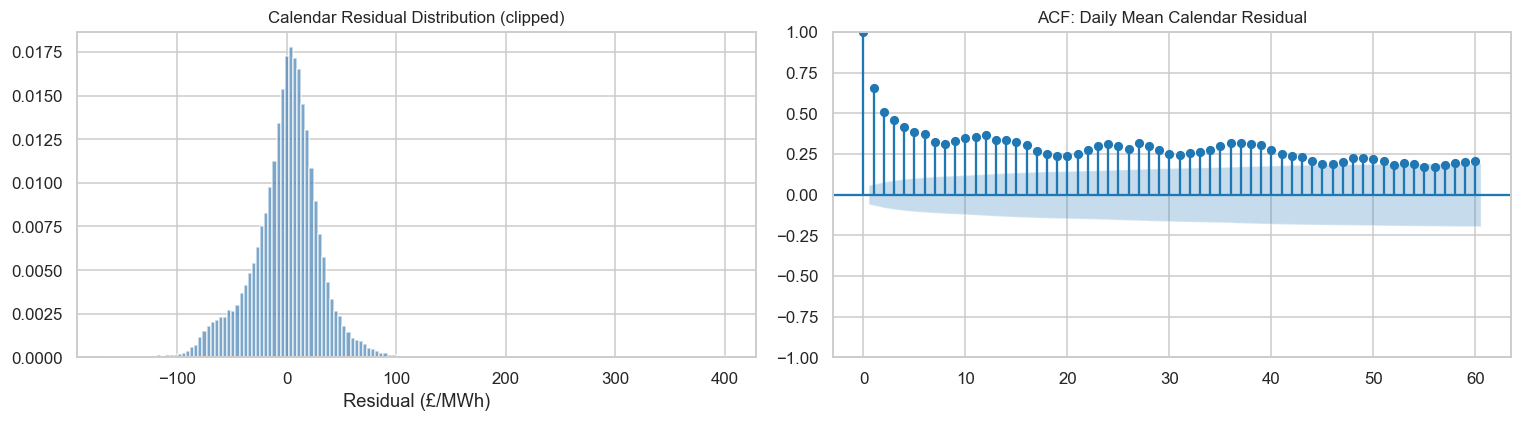

In [34]:
# ── Residual distribution + daily-level ACF ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(resid_cal.clip(-200, 400), bins=150, density=True, color="steelblue", alpha=0.7)
axes[0].set_title("Calendar Residual Distribution (clipped)")
axes[0].set_xlabel("Residual (£/MWh)")

# Daily-level mean residual ACF
daily_resid = df_hh_eda.groupby("settlement_date")["resid_calendar"].mean().dropna()
plot_acf(daily_resid, lags=60, ax=axes[1], title="ACF: Daily Mean Calendar Residual")

plt.tight_layout()
plt.show()

Calendar features (settlement period, weekday, month) explain ~20% of the variance in half-hour prices. but 80% of price variation comes from things calendar can't capture: how tight the system is on a given day, wind output, gas prices, demand surprises, etc. This justifies adding fundamental and lagged features.

he residuals are extremely right-skewed with very fat tails. This is the spike signature: most residuals are moderate, but a small number are enormously positive (scarcity spikes). Standard regression assumptions are badly violated. This warrants using quantile regression (LightGBM).

Residuals are autocorrelated after removing calendar effects means:
- Prices on adjacent days are more similar than calendar structure alone can explain                                     
- There are persistent multi-day episodes — high-price stretches, negative-price stretches — driven by things like prolonged low wind or a cold spell that last several days    
- lagged price features will add real signal on top of calendar features. The 1-day and 7-day same-period lags are worth keeping. The 7-day lag captures weekly periodicity that the weekday dummy doesn't fully absorb.      

## 7 · Lagged Price Dependence EDA

In [35]:
# ── Pooled lag correlations ────────────────────────────────────────────────────
lag_cols = [c for c in df_hh.columns if c.startswith("price_lag")]
corr_rows = []
for col in lag_cols:
    sub = df_hh[["price", col]].dropna()
    pearson = sub.corr().iloc[0, 1]
    spearman = sub.corr(method="spearman").iloc[0, 1]
    corr_rows.append({"lag_feature": col, "pearson": pearson, "spearman": spearman})
corr_df = pd.DataFrame(corr_rows)
print("=== Pooled Lag Correlations ===")
print(corr_df.round(4).to_string(index=False))

=== Pooled Lag Correlations ===
lag_feature  pearson  spearman
price_lag1d   0.5402    0.6463
price_lag2d   0.4524    0.5627
price_lag7d   0.4153    0.5176


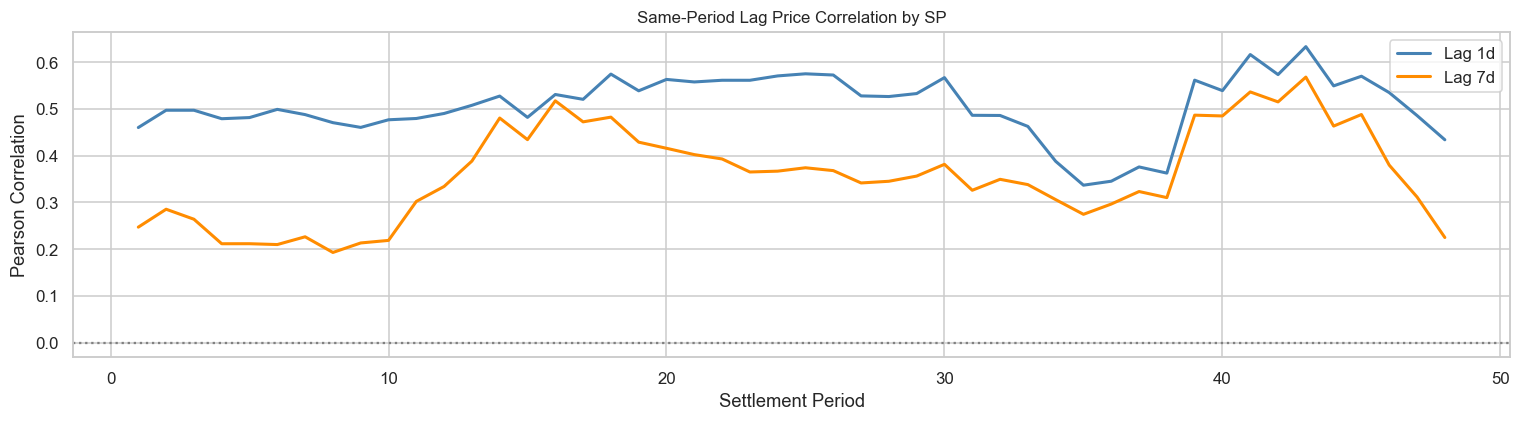

In [36]:
# ── Lag correlation by SP ──────────────────────────────────────────────────────
lag1_by_sp  = df_hh.groupby("settlement_period")[["price", "price_lag1d"]].corr().iloc[0::2, -1].reset_index()
lag7_by_sp  = df_hh.groupby("settlement_period")[["price", "price_lag7d"]].corr().iloc[0::2, -1].reset_index()

sp_idx = df_hh["settlement_period"].unique()
sp_idx = sorted(sp_idx)

lag1_corr_sp = df_hh.groupby("settlement_period").apply(
    lambda g: g[["price", "price_lag1d"]].dropna().corr().iloc[0, 1]
)
lag7_corr_sp = df_hh.groupby("settlement_period").apply(
    lambda g: g[["price", "price_lag7d"]].dropna().corr().iloc[0, 1]
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(lag1_corr_sp.index, lag1_corr_sp.values, label="Lag 1d", color="steelblue", lw=2)
ax.plot(lag7_corr_sp.index, lag7_corr_sp.values, label="Lag 7d", color="darkorange", lw=2)
ax.axhline(0, ls=":", color="grey")
ax.set_xlabel("Settlement Period")
ax.set_ylabel("Pearson Correlation")
ax.set_title("Same-Period Lag Price Correlation by SP")
ax.legend()
plt.tight_layout()
plt.show()

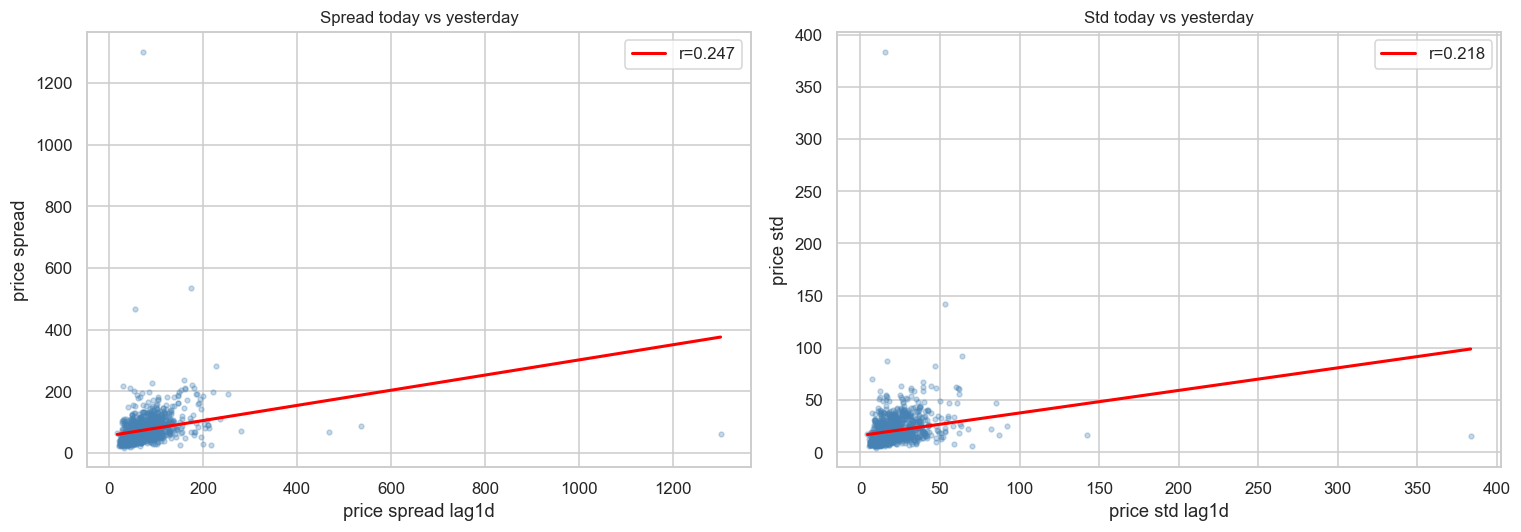

In [37]:
# ── Daily level: spread vs yesterday-spread, std vs yesterday-std ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (x_col, y_col, title) in zip(axes, [
    ("price_spread_lag1d", "price_spread", "Spread today vs yesterday"),
    ("price_std_lag1d",    "price_std",    "Std today vs yesterday"),
]):
    sub = df_day[[x_col, y_col]].dropna()
    ax.scatter(sub[x_col], sub[y_col], alpha=0.3, s=10, color="steelblue")
    # Regression line
    m, b, r, *_ = stats.linregress(sub[x_col], sub[y_col])
    xl = np.linspace(sub[x_col].min(), sub[x_col].max(), 100)
    ax.plot(xl, m * xl + b, color="red", lw=2, label=f"r={r:.3f}")
    ax.set_xlabel(x_col.replace("_", " "))
    ax.set_ylabel(y_col.replace("_", " "))
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

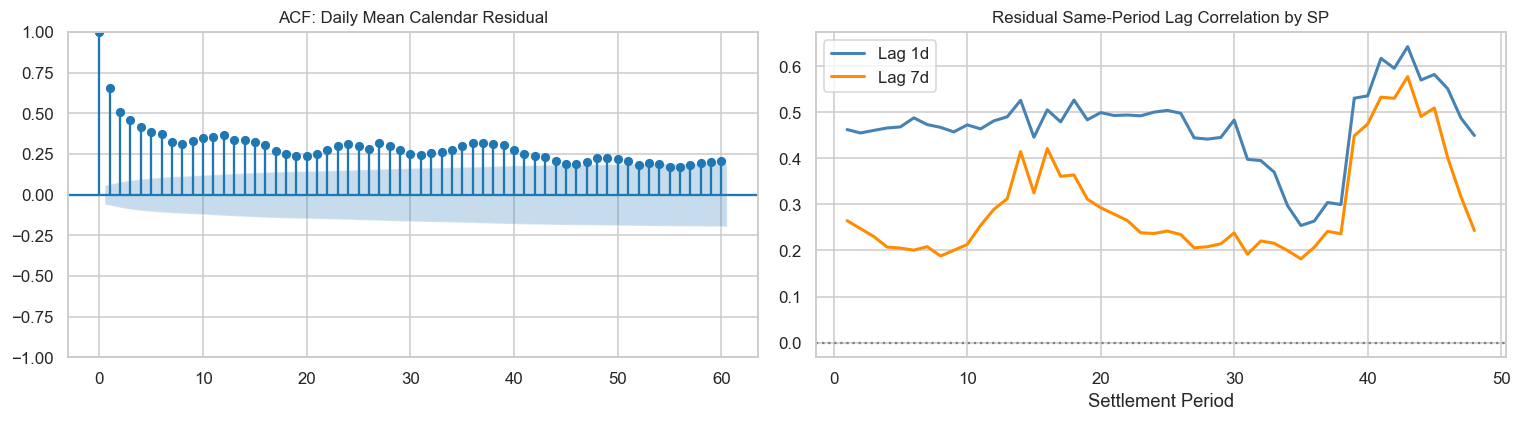

In [38]:
# ── Residual ACF and same-period residual lag correlations ─────────────────────
# Build daily residual mean for ACF
resid_series = df_hh_eda.groupby("settlement_date")["resid_calendar"].mean().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(resid_series, lags=60, ax=axes[0], title="ACF: Daily Mean Calendar Residual")

# Same-period residual: lag-1d and lag-7d
if "resid_calendar" in df_hh_eda.columns:
    df_hh_eda = df_hh_eda.sort_values(["settlement_period", "settlement_date"])
    df_hh_eda["resid_lag1d"] = df_hh_eda.groupby("settlement_period")["resid_calendar"].shift(1)
    df_hh_eda["resid_lag7d"] = df_hh_eda.groupby("settlement_period")["resid_calendar"].shift(7)

    resid_lag1_corr = df_hh_eda.groupby("settlement_period").apply(
        lambda g: g[["resid_calendar", "resid_lag1d"]].dropna().corr().iloc[0, 1]
    )
    resid_lag7_corr = df_hh_eda.groupby("settlement_period").apply(
        lambda g: g[["resid_calendar", "resid_lag7d"]].dropna().corr().iloc[0, 1]
    )
    axes[1].plot(resid_lag1_corr.index, resid_lag1_corr.values, label="Lag 1d", color="steelblue", lw=2)
    axes[1].plot(resid_lag7_corr.index, resid_lag7_corr.values, label="Lag 7d", color="darkorange", lw=2)
    axes[1].axhline(0, ls=":", color="grey")
    axes[1].set_title("Residual Same-Period Lag Correlation by SP")
    axes[1].set_xlabel("Settlement Period")
    axes[1].legend()

plt.tight_layout()
plt.show()

In [39]:
# ── Compare raw vs residual autocorrelation table ──────────────────────────────
raw_lag1 = df_hh.groupby("settlement_period").apply(
    lambda g: g[["price", "price_lag1d"]].dropna().corr().iloc[0, 1]
)
raw_lag7 = df_hh.groupby("settlement_period").apply(
    lambda g: g[["price", "price_lag7d"]].dropna().corr().iloc[0, 1]
)

autocorr_compare = pd.DataFrame({
    "raw_lag1d": raw_lag1,
    "raw_lag7d": raw_lag7,
    "resid_lag1d": resid_lag1_corr if 'resid_lag1_corr' in dir() else np.nan,
    "resid_lag7d": resid_lag7_corr if 'resid_lag7_corr' in dir() else np.nan,
}).round(4)

print("=== Raw vs Residual Autocorrelation by SP (sample every 4 SPs) ===")
print(autocorr_compare.iloc[::4].to_string())

=== Raw vs Residual Autocorrelation by SP (sample every 4 SPs) ===
                   raw_lag1d  raw_lag7d  resid_lag1d  resid_lag7d
settlement_period                                                
1                     0.4605     0.2472       0.4626       0.2649
5                     0.4818     0.2117       0.4685       0.2052
9                     0.4608     0.2133       0.4576       0.2004
13                    0.5081     0.3886       0.4904       0.3125
17                    0.5209     0.4727       0.4793       0.3611
21                    0.5581     0.4025       0.4932       0.2791
25                    0.5756     0.3743       0.5043       0.2422
29                    0.5332     0.3566       0.4456       0.2144
33                    0.4629     0.3383       0.3702       0.2156
37                    0.3761     0.3235       0.3042       0.2417
41                    0.6168     0.5368       0.6173       0.5330
45                    0.5704     0.4884       0.5823       0.5095


The residual autocorrelations (0.37–0.62 at lag-1d, 0.20–0.53 at lag-7d) are nearly as large as the raw autocorrelations. the autocorrelation in prices is not explained by calendar structure — it's coming from something else entirely, and lagged price features will capture that something else directly.

## 8 · Fundamental Driver EDA

In [40]:
def decile_analysis(df, driver_col, target_col="price", n_bins=10, label=None):
    """Bin driver into deciles and compute price quantiles within each bin."""
    sub = df[[driver_col, target_col]].dropna()
    sub = sub.copy()
    try:
        sub["decile"] = pd.qcut(sub[driver_col], n_bins, labels=False, duplicates="drop")
    except ValueError:
        sub["decile"] = pd.cut(sub[driver_col], n_bins, labels=False)

    result = sub.groupby("decile")[target_col].agg(
        P10=lambda s: s.quantile(0.10),
        P50=lambda s: s.quantile(0.50),
        P90=lambda s: s.quantile(0.90),
        P95=lambda s: s.quantile(0.95),
    )
    return result


drivers = ["demand", "wind_da", "emb_solar", "emb_wind", "net_load"]
drivers_present = [d for d in drivers if d in df_hh.columns]
print(f"Available drivers: {drivers_present}")

Available drivers: ['demand', 'wind_da', 'emb_solar', 'emb_wind', 'net_load']


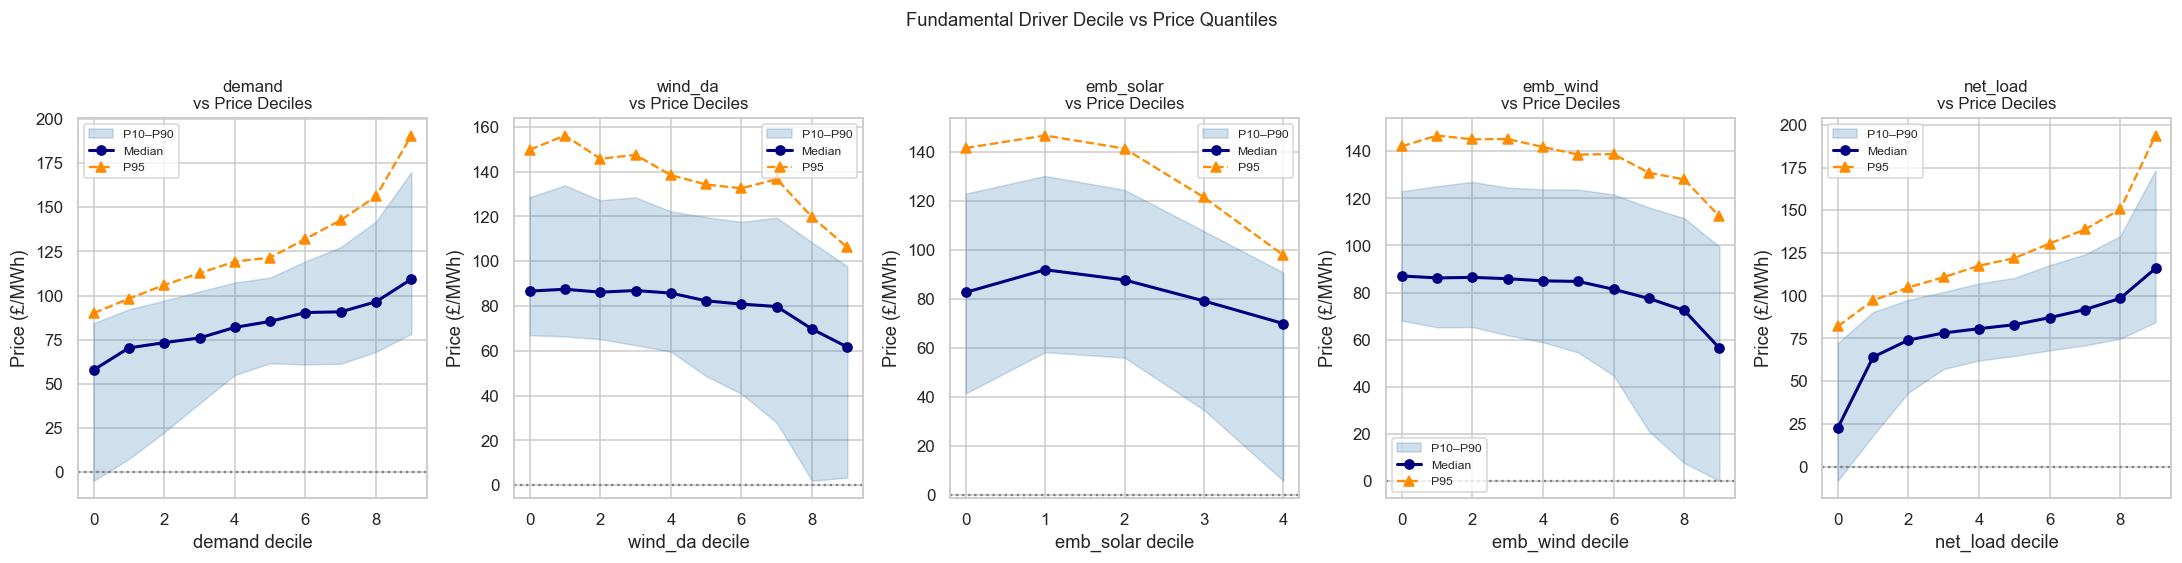

In [41]:
# ── Decile analysis: driver vs price quantiles ─────────────────────────────────
n_drivers = len(drivers_present)
fig, axes = plt.subplots(1, n_drivers, figsize=(4 * n_drivers, 5))
if n_drivers == 1:
    axes = [axes]

for ax, driver in zip(axes, drivers_present):
    da = decile_analysis(df_hh, driver, "price")
    ax.fill_between(da.index, da["P10"], da["P90"], alpha=0.25, color="steelblue", label="P10–P90")
    ax.plot(da.index, da["P50"], "o-", color="navy", lw=2, label="Median")
    ax.plot(da.index, da["P95"], "^--", color="darkorange", lw=1.5, label="P95")
    ax.axhline(0, ls=":", color="grey")
    ax.set_title(f"{driver}\nvs Price Deciles")
    ax.set_xlabel(f"{driver} decile")
    ax.set_ylabel("Price (£/MWh)")
    ax.legend(fontsize=8)

plt.suptitle("Fundamental Driver Decile vs Price Quantiles", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

`net_load` gives the cleanest signal.

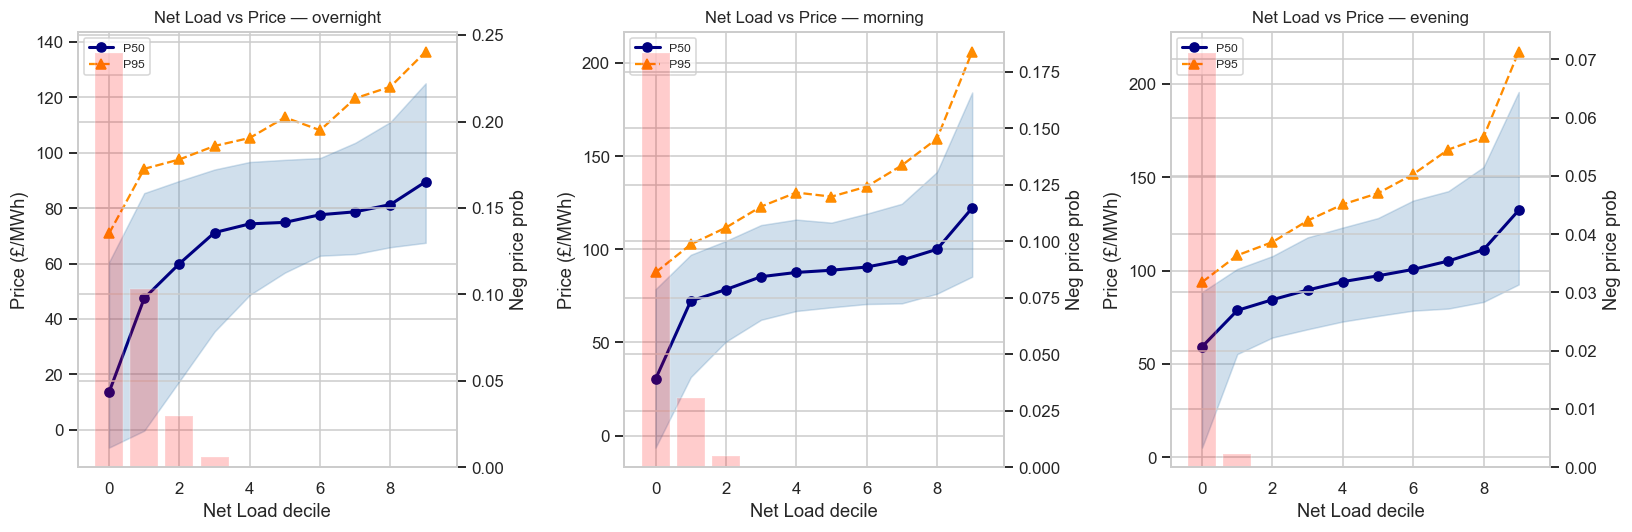

In [42]:
# ── Period-specific analysis: overnight/morning/evening ───────────────────────
OVERNIGHT_SPS = list(range(1, 13))   # 00:00–06:00

period_masks = {
    "overnight": df_hh["settlement_period"].isin(OVERNIGHT_SPS),
    "morning": df_hh["settlement_period"].isin(MORNING_SPS),
    "evening": df_hh["settlement_period"].isin(EVENING_SPS),
}

driver = "net_load"
if driver in df_hh.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (period, mask) in zip(axes, period_masks.items()):
        sub_p = df_hh[mask]
        da = decile_analysis(sub_p, driver, "price")
        ax.fill_between(da.index, da["P10"], da["P90"], alpha=0.25, color="steelblue")
        ax.plot(da.index, da["P50"], "o-", color="navy", lw=2, label="P50")
        ax.plot(da.index, da["P95"], "^--", color="darkorange", lw=1.5, label="P95")
        neg_prob = sub_p.groupby(pd.qcut(sub_p[driver], 10, duplicates="drop"))["price"].apply(
            lambda s: (s < NEGATIVE_THRESHOLD).mean()
        ).values
        ax2 = ax.twinx()
        ax2.bar(range(len(neg_prob)), neg_prob, alpha=0.2, color="red", label="Neg prob")
        ax2.set_ylabel("Neg price prob")
        ax.set_title(f"Net Load vs Price — {period}")
        ax.set_xlabel("Net Load decile")
        ax.set_ylabel("Price (£/MWh)")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

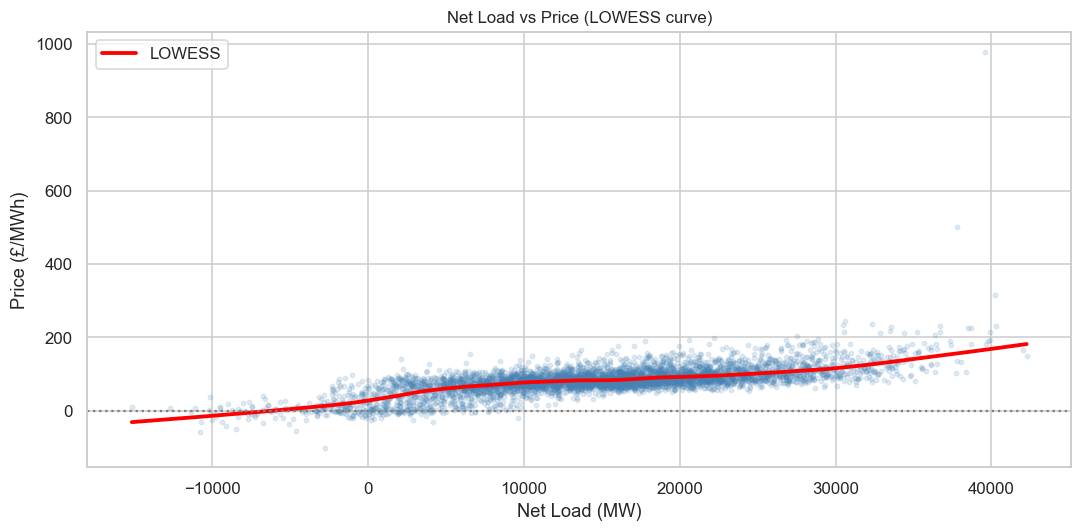

In [43]:
# ── Nonlinear effect: net_load vs price (LOWESS) ──────────────────────────────
if "net_load" in df_hh.columns:
    from statsmodels.nonparametric.smoothers_lowess import lowess

    sub_nl = df_hh[["net_load", "price"]].dropna().sample(min(5000, len(df_hh)), random_state=42)
    smoothed = lowess(sub_nl["price"], sub_nl["net_load"], frac=0.15, return_sorted=True)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(sub_nl["net_load"], sub_nl["price"], alpha=0.15, s=8, color="steelblue")
    ax.plot(smoothed[:, 0], smoothed[:, 1], color="red", lw=2.5, label="LOWESS")
    ax.axhline(0, ls=":", color="grey")
    ax.set_xlabel("Net Load (MW)")
    ax.set_ylabel("Price (£/MWh)")
    ax.set_title("Net Load vs Price (LOWESS curve)")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [44]:
# ── Net load vs demand informativeness comparison ──────────────────────────────
if "demand" in df_hh.columns and "net_load" in df_hh.columns:
    from sklearn.linear_model import Ridge

    sub_cmp = df_hh[["price", "demand", "net_load"]].dropna()
    r_demand  = np.corrcoef(sub_cmp["demand"],   sub_cmp["price"])[0, 1]
    r_netload = np.corrcoef(sub_cmp["net_load"], sub_cmp["price"])[0, 1]
    print(f"Pearson corr(demand, price)   : {r_demand:.4f}")
    print(f"Pearson corr(net_load, price) : {r_netload:.4f}")
    print("→ Net load combines demand + renewables; typically more informative than raw demand alone.")

Pearson corr(demand, price)   : 0.5353
Pearson corr(net_load, price) : 0.6709
→ Net load combines demand + renewables; typically more informative than raw demand alone.


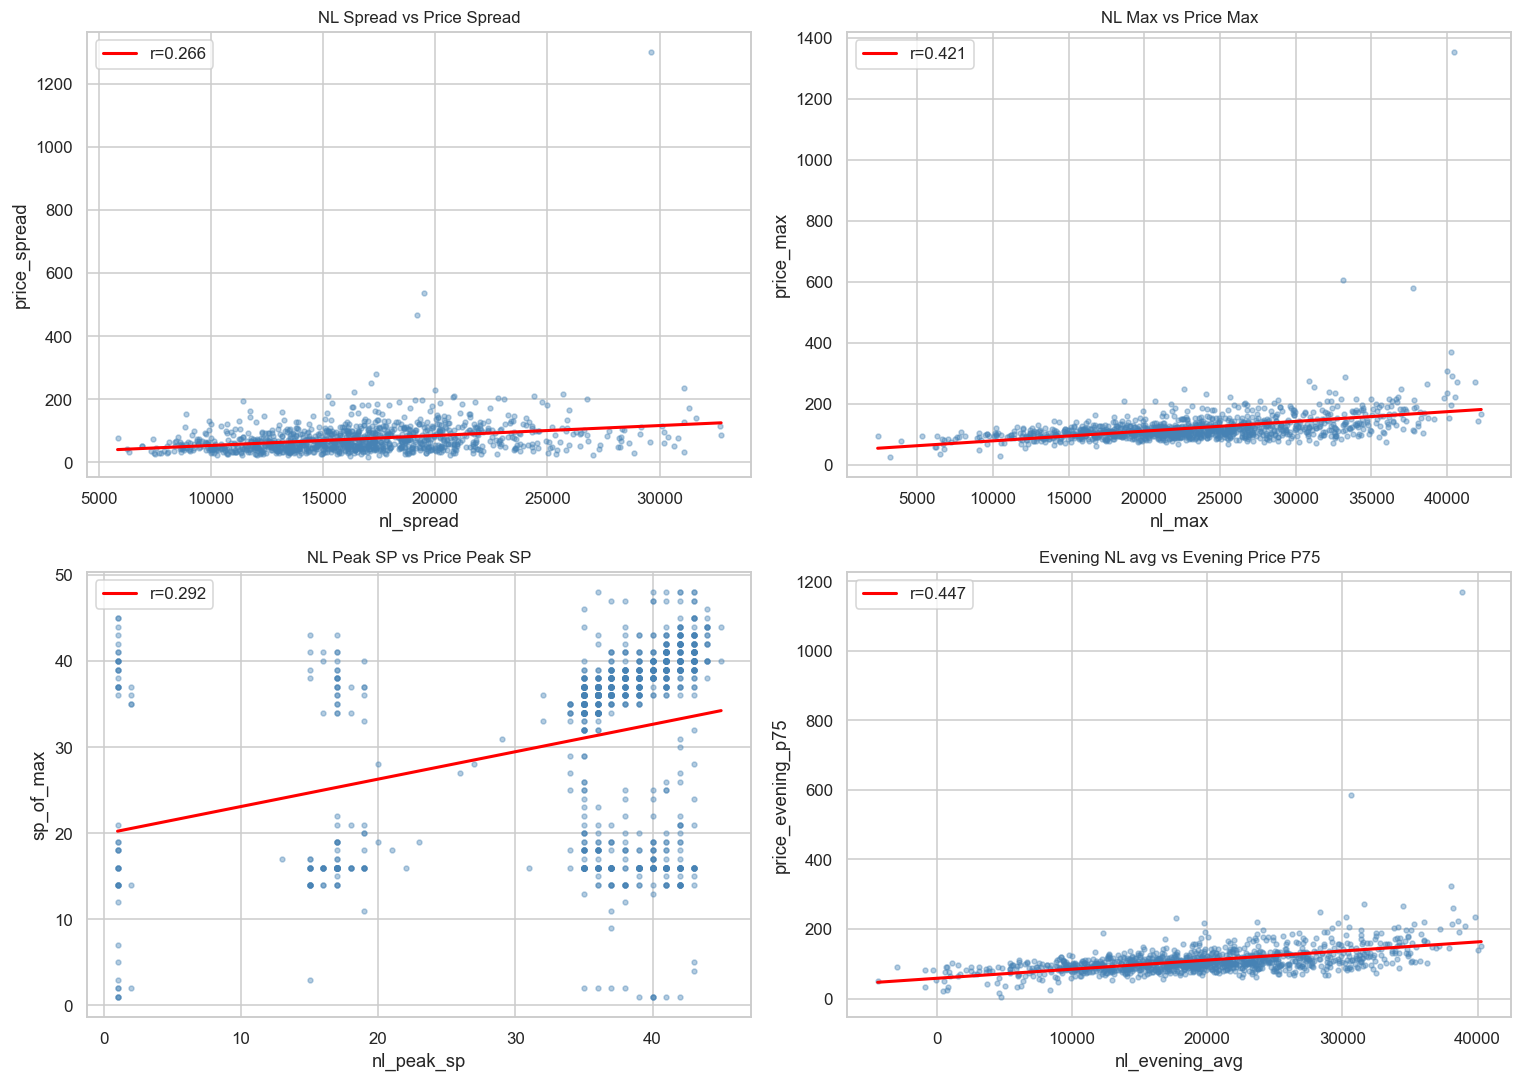

In [45]:
# ── Daily shape scatter plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

scatter_pairs = [
    ("nl_spread", "price_spread", "NL Spread vs Price Spread"),
    ("nl_max",    "price_max",    "NL Max vs Price Max"),
    ("nl_peak_sp","sp_of_max",   "NL Peak SP vs Price Peak SP"),
    ("nl_evening_avg", "price_evening_p75", "Evening NL avg vs Evening Price P75"),
]

for ax, (x_col, y_col, title) in zip(axes.flat, scatter_pairs):
    if x_col in df_day.columns and y_col in df_day.columns:
        sub = df_day[[x_col, y_col]].dropna()
        ax.scatter(sub[x_col], sub[y_col], alpha=0.4, s=10, color="steelblue")
        m, b, r, *_ = stats.linregress(sub[x_col], sub[y_col])
        xl = np.linspace(sub[x_col].min(), sub[x_col].max(), 100)
        ax.plot(xl, m*xl + b, color="red", lw=2, label=f"r={r:.3f}")
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_title(title)
        ax.legend()
    else:
        ax.text(0.5, 0.5, f"{x_col}\nor\n{y_col}\nnot available", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)

plt.tight_layout()
plt.show()

DRM/LoLP columns available: ['drm_mean', 'drm_min', 'lolp_max', 'drm_eve_mean']


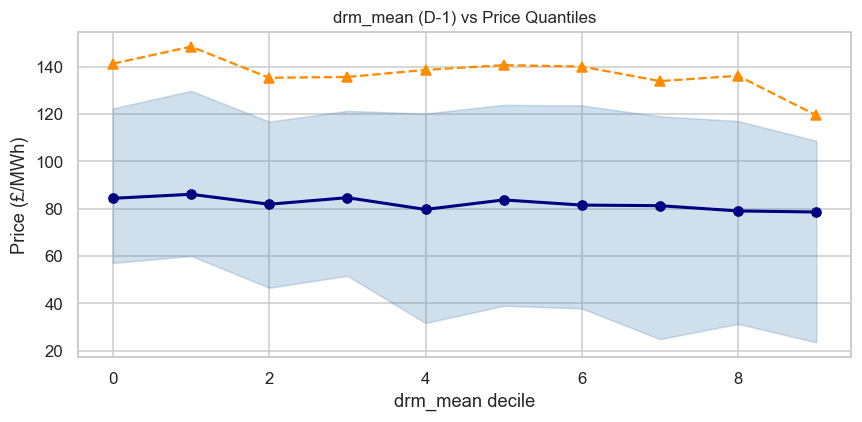

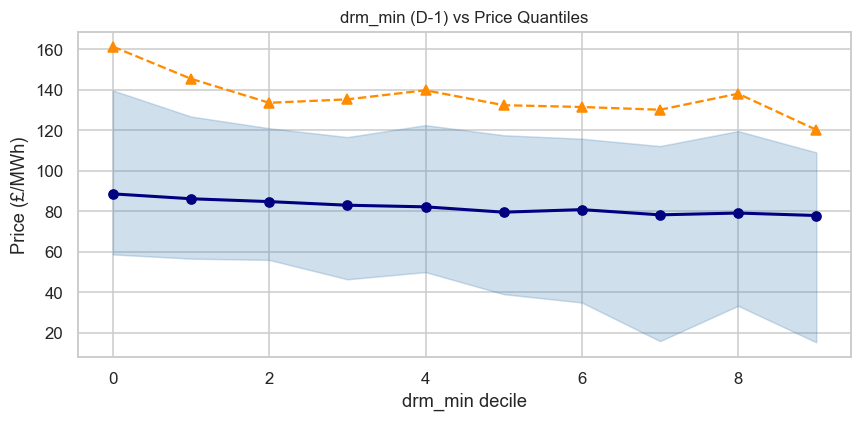

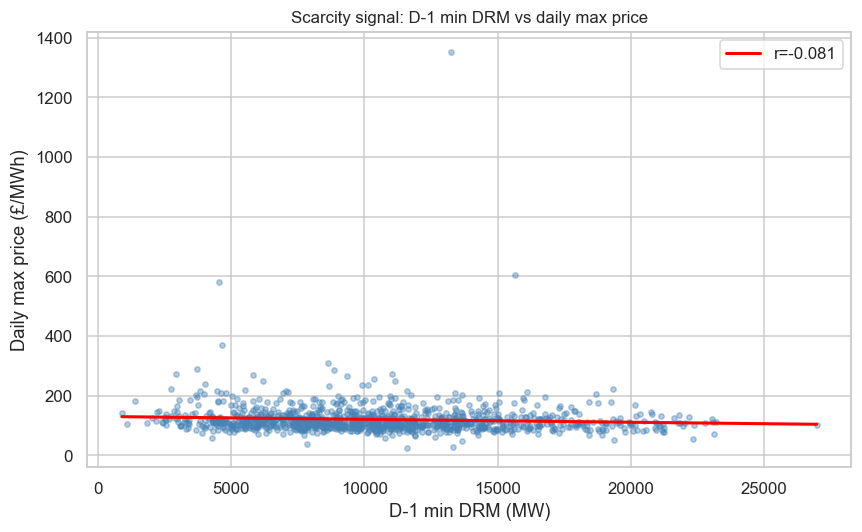

In [46]:
# ── DRM / LoLP analysis ────────────────────────────────────────────────────────
# DRM/LoLP columns are already D-2 features merged into df_hh (no _lag1d suffix needed).
drm_cols = [c for c in df_hh.columns if c in ("drm_mean", "drm_min", "drm_eve_mean", "lolp_max")]
print(f"DRM/LoLP columns available: {drm_cols}")

if drm_cols:
    for col in drm_cols[:2]:  # first two columns
        da = decile_analysis(df_hh, col, "price")
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.fill_between(da.index, da["P10"], da["P90"], alpha=0.25, color="steelblue")
        ax.plot(da.index, da["P50"], "o-", color="navy", lw=2)
        ax.plot(da.index, da["P95"], "^--", color="darkorange", lw=1.5)
        ax.set_title(f"{col} (D-1) vs Price Quantiles")
        ax.set_xlabel(f"{col} decile")
        ax.set_ylabel("Price (£/MWh)")
        plt.tight_layout()
        plt.show()

    # Scatter: D-1 min DRM vs daily max price
    drm_min_col = "drm_min" if "drm_min" in df_day.columns else None
    if drm_min_col:
        sub_drm = df_day[[drm_min_col, "price_max"]].dropna()
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.scatter(sub_drm[drm_min_col], sub_drm["price_max"], alpha=0.4, s=12, color="steelblue")
        m, b, r, *_ = stats.linregress(sub_drm[drm_min_col], sub_drm["price_max"])
        xl = np.linspace(sub_drm[drm_min_col].min(), sub_drm[drm_min_col].max(), 100)
        ax.plot(xl, m * xl + b, color="red", lw=2, label=f"r={r:.3f}")
        ax.set_xlabel("D-1 min DRM (MW)")
        ax.set_ylabel("Daily max price (£/MWh)")
        ax.set_title("Scarcity signal: D-1 min DRM vs daily max price")
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print("⚠ DRM/LoLP driver analysis skipped — columns not found in df_hh.")

Interconnector column: ic_total_mean


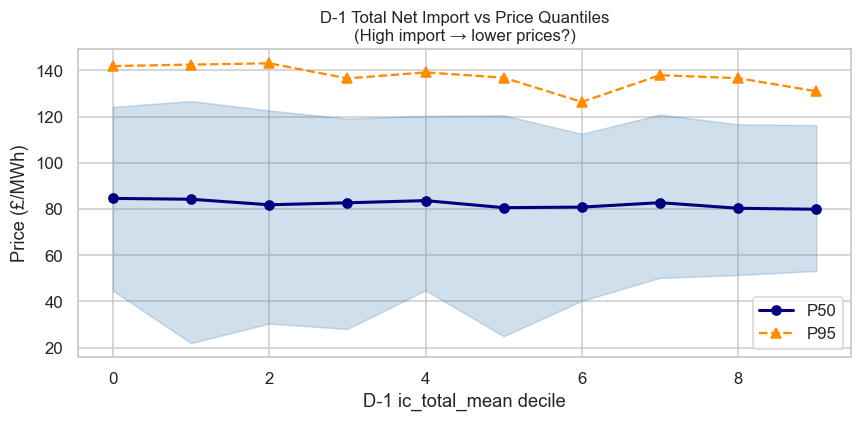

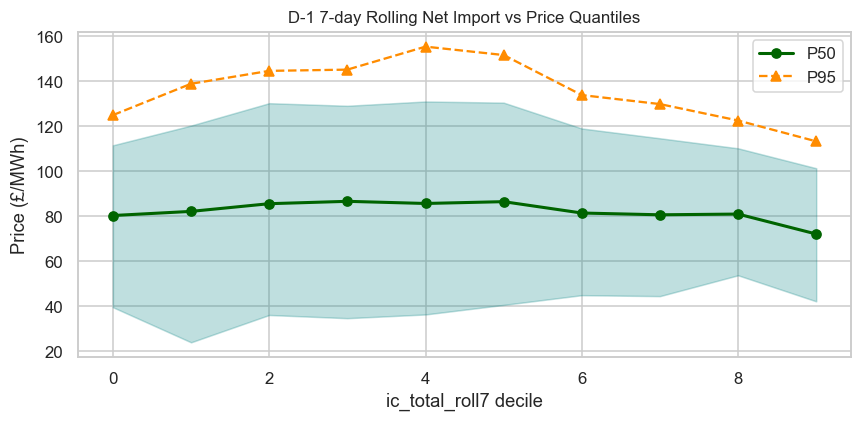

In [47]:
# ── Interconnector analysis ────────────────────────────────────────────────────
# ic_total_mean is the D-2 total net import, already merged into df_hh.
ic_col = "ic_total_mean" if "ic_total_mean" in df_hh.columns else None
print(f"Interconnector column: {ic_col}")

if ic_col:
    da = decile_analysis(df_hh, ic_col, "price")
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.fill_between(da.index, da["P10"], da["P90"], alpha=0.25, color="steelblue")
    ax.plot(da.index, da["P50"], "o-", color="navy", lw=2, label="P50")
    ax.plot(da.index, da["P95"], "^--", color="darkorange", lw=1.5, label="P95")
    ax.set_title("D-1 Total Net Import vs Price Quantiles\n(High import → lower prices?)")
    ax.set_xlabel("D-1 ic_total_mean decile")
    ax.set_ylabel("Price (£/MWh)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Also plot 7-day rolling IC trend if available
    ic_roll_col = "ic_total_roll7" if "ic_total_roll7" in df_hh.columns else None
    if ic_roll_col:
        da2 = decile_analysis(df_hh, ic_roll_col, "price")
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.fill_between(da2.index, da2["P10"], da2["P90"], alpha=0.25, color="teal")
        ax.plot(da2.index, da2["P50"], "o-", color="darkgreen", lw=2, label="P50")
        ax.plot(da2.index, da2["P95"], "^--", color="darkorange", lw=1.5, label="P95")
        ax.set_title("D-1 7-day Rolling Net Import vs Price Quantiles")
        ax.set_xlabel("ic_total_roll7 decile")
        ax.set_ylabel("Price (£/MWh)")
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print("⚠ Interconnector driver analysis skipped — ic_total_mean not found in df_hh.")

Drop IC features, keep DRM features specifically for tail quantile modelling.

## 9 · Redundancy and Feature Screening

In [48]:
# ── Candidate feature set for correlation analysis ─────────────────────────────
candidate_features = [
    "settlement_period", "sp_sin", "sp_cos",
    "weekday", "is_weekend", "month", "doy_sin", "doy_cos",
    "demand", "wind_da", "net_load",
    "price_lag1d", "price_lag2d", "price_lag7d",
    "price_roll3d_mean", "price_roll7d_mean", "price_roll3d_std", "price_roll7d_std",
]
if "emb_solar" in df_hh.columns:
    candidate_features.append("emb_solar")
if "emb_wind" in df_hh.columns:
    candidate_features.append("emb_wind")

# Add DRM/LoLP columns (already D-1 features, no _lag1d suffix)
for c in ("drm_mean", "drm_min", "drm_eve_mean", "lolp_max", "drm_roll7"):
    if c in df_hh.columns and c not in candidate_features:
        candidate_features.append(c)

# Add interconnector columns
for c in ("ic_total_mean", "ic_total_roll7"):
    if c in df_hh.columns and c not in candidate_features:
        candidate_features.append(c)

feat_present = [f for f in candidate_features if f in df_hh.columns]
print(f"Candidate features for screening ({len(feat_present)}): {feat_present}")

Candidate features for screening (27): ['settlement_period', 'sp_sin', 'sp_cos', 'weekday', 'is_weekend', 'month', 'doy_sin', 'doy_cos', 'demand', 'wind_da', 'net_load', 'price_lag1d', 'price_lag2d', 'price_lag7d', 'price_roll3d_mean', 'price_roll7d_mean', 'price_roll3d_std', 'price_roll7d_std', 'emb_solar', 'emb_wind', 'drm_mean', 'drm_min', 'drm_eve_mean', 'lolp_max', 'drm_roll7', 'ic_total_mean', 'ic_total_roll7']


In [49]:
# ── Missingness summary table ──────────────────────────────────────────────────
miss_screen = df_hh[feat_present + ["price"]].isnull().mean() * 100
print("=== Missingness (%) for Candidate Features ===")
print(miss_screen.round(2).to_string())

=== Missingness (%) for Candidate Features ===
settlement_period    0.00
sp_sin               0.00
sp_cos               0.00
weekday              0.00
is_weekend           0.00
month                0.00
doy_sin              0.00
doy_cos              0.00
demand               0.00
wind_da              0.00
net_load             0.00
price_lag1d          0.09
price_lag2d          0.17
price_lag7d          0.61
price_roll3d_mean    0.17
price_roll7d_mean    0.17
price_roll3d_std     0.17
price_roll7d_std     0.17
emb_solar            0.00
emb_wind             0.00
drm_mean             0.17
drm_min              0.17
drm_eve_mean         0.17
lolp_max             0.17
drm_roll7            0.17
ic_total_mean        0.17
ic_total_roll7       0.17
price                0.00


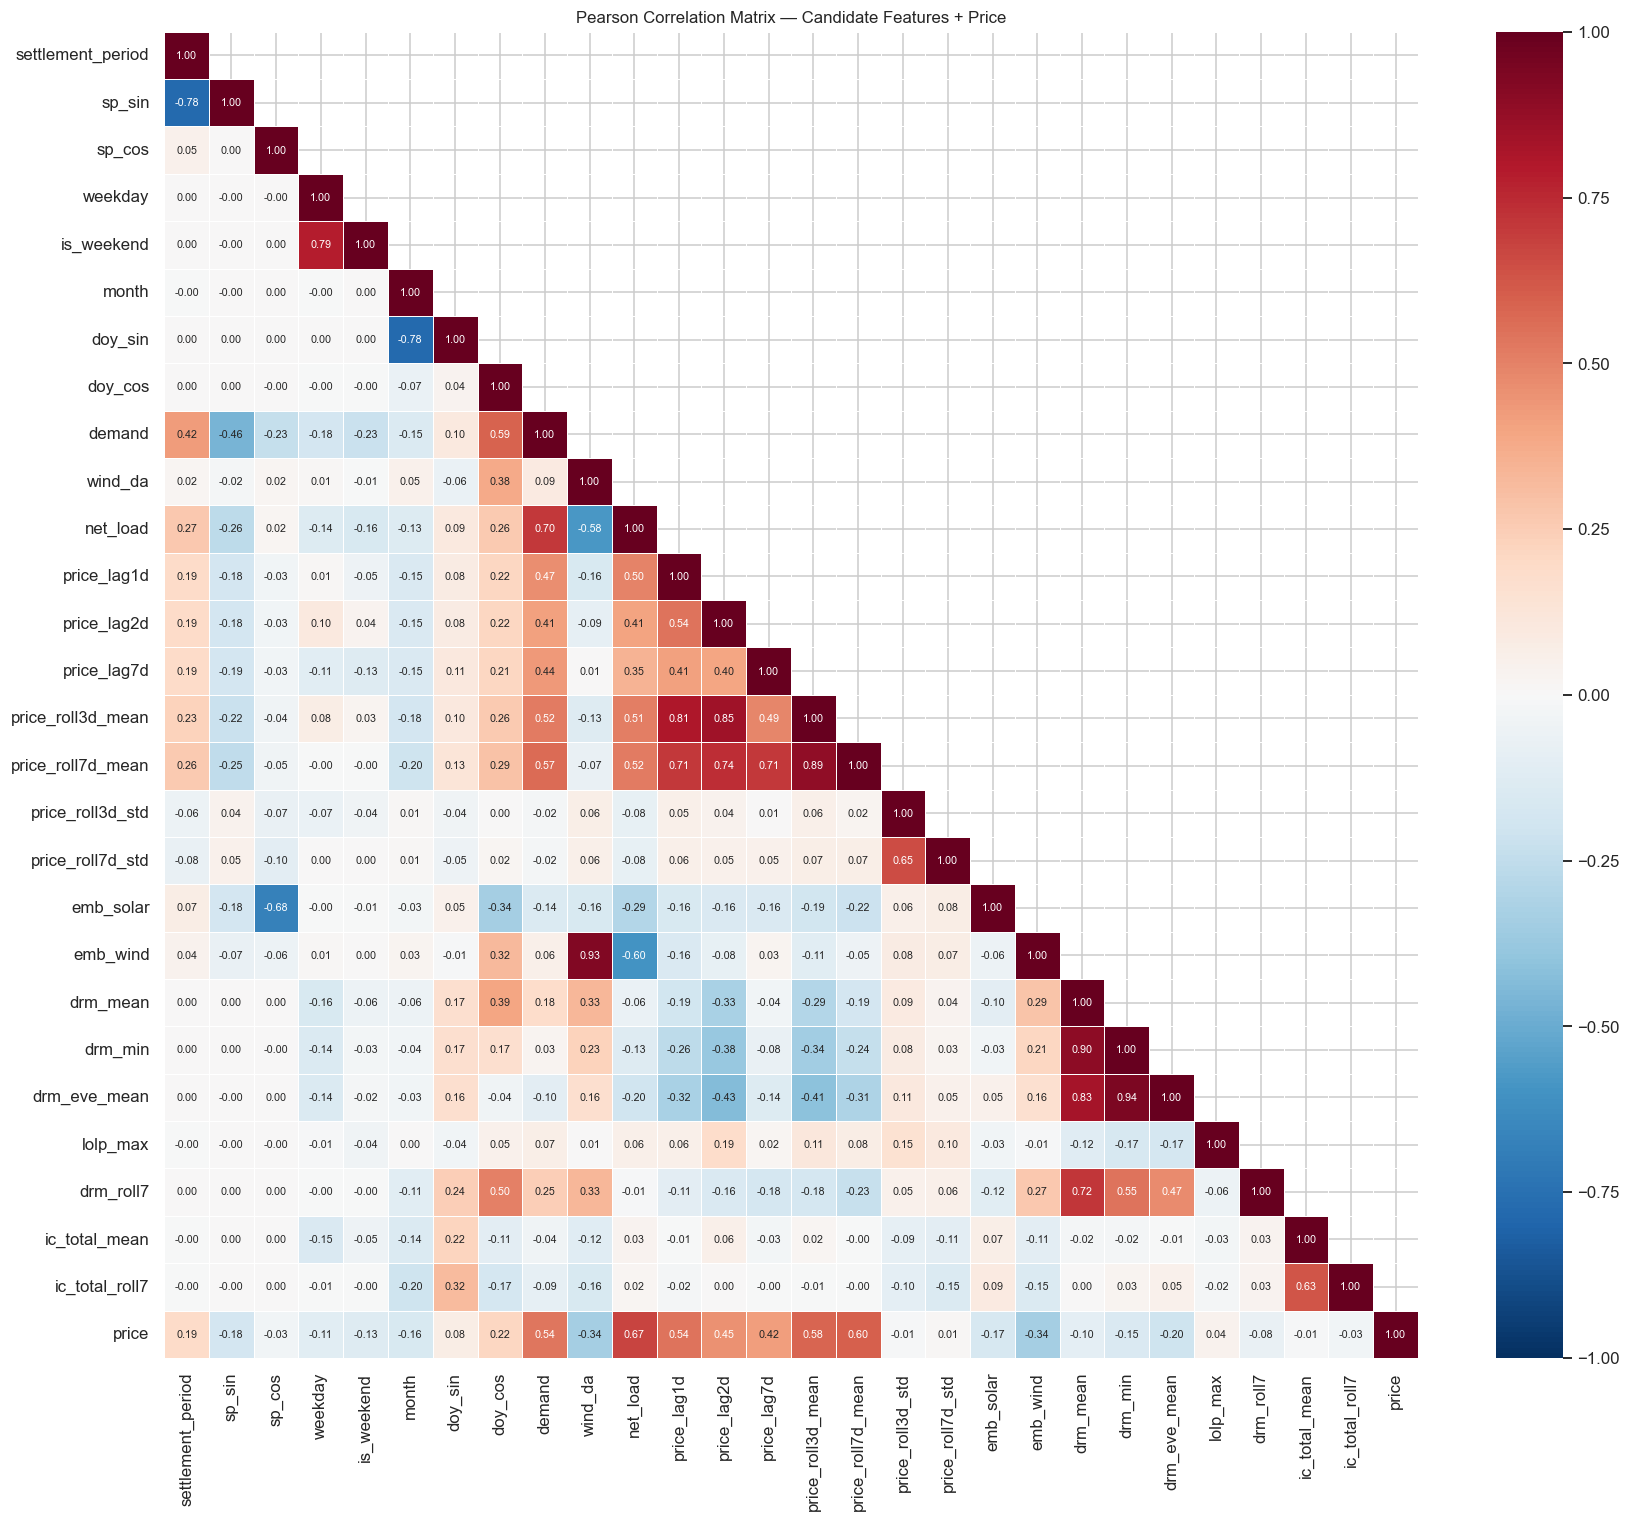

In [50]:
# ── Pearson correlation matrix ─────────────────────────────────────────────────
corr_feat_df = df_hh[feat_present + ["price"]].dropna()
pearson_corr = corr_feat_df.corr(method="pearson")

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(pearson_corr, dtype=bool), k=1)
sns.heatmap(
    pearson_corr, mask=mask, ax=ax, cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 7},
    linewidths=0.4
)
ax.set_title("Pearson Correlation Matrix — Candidate Features + Price")
plt.tight_layout()
plt.show()

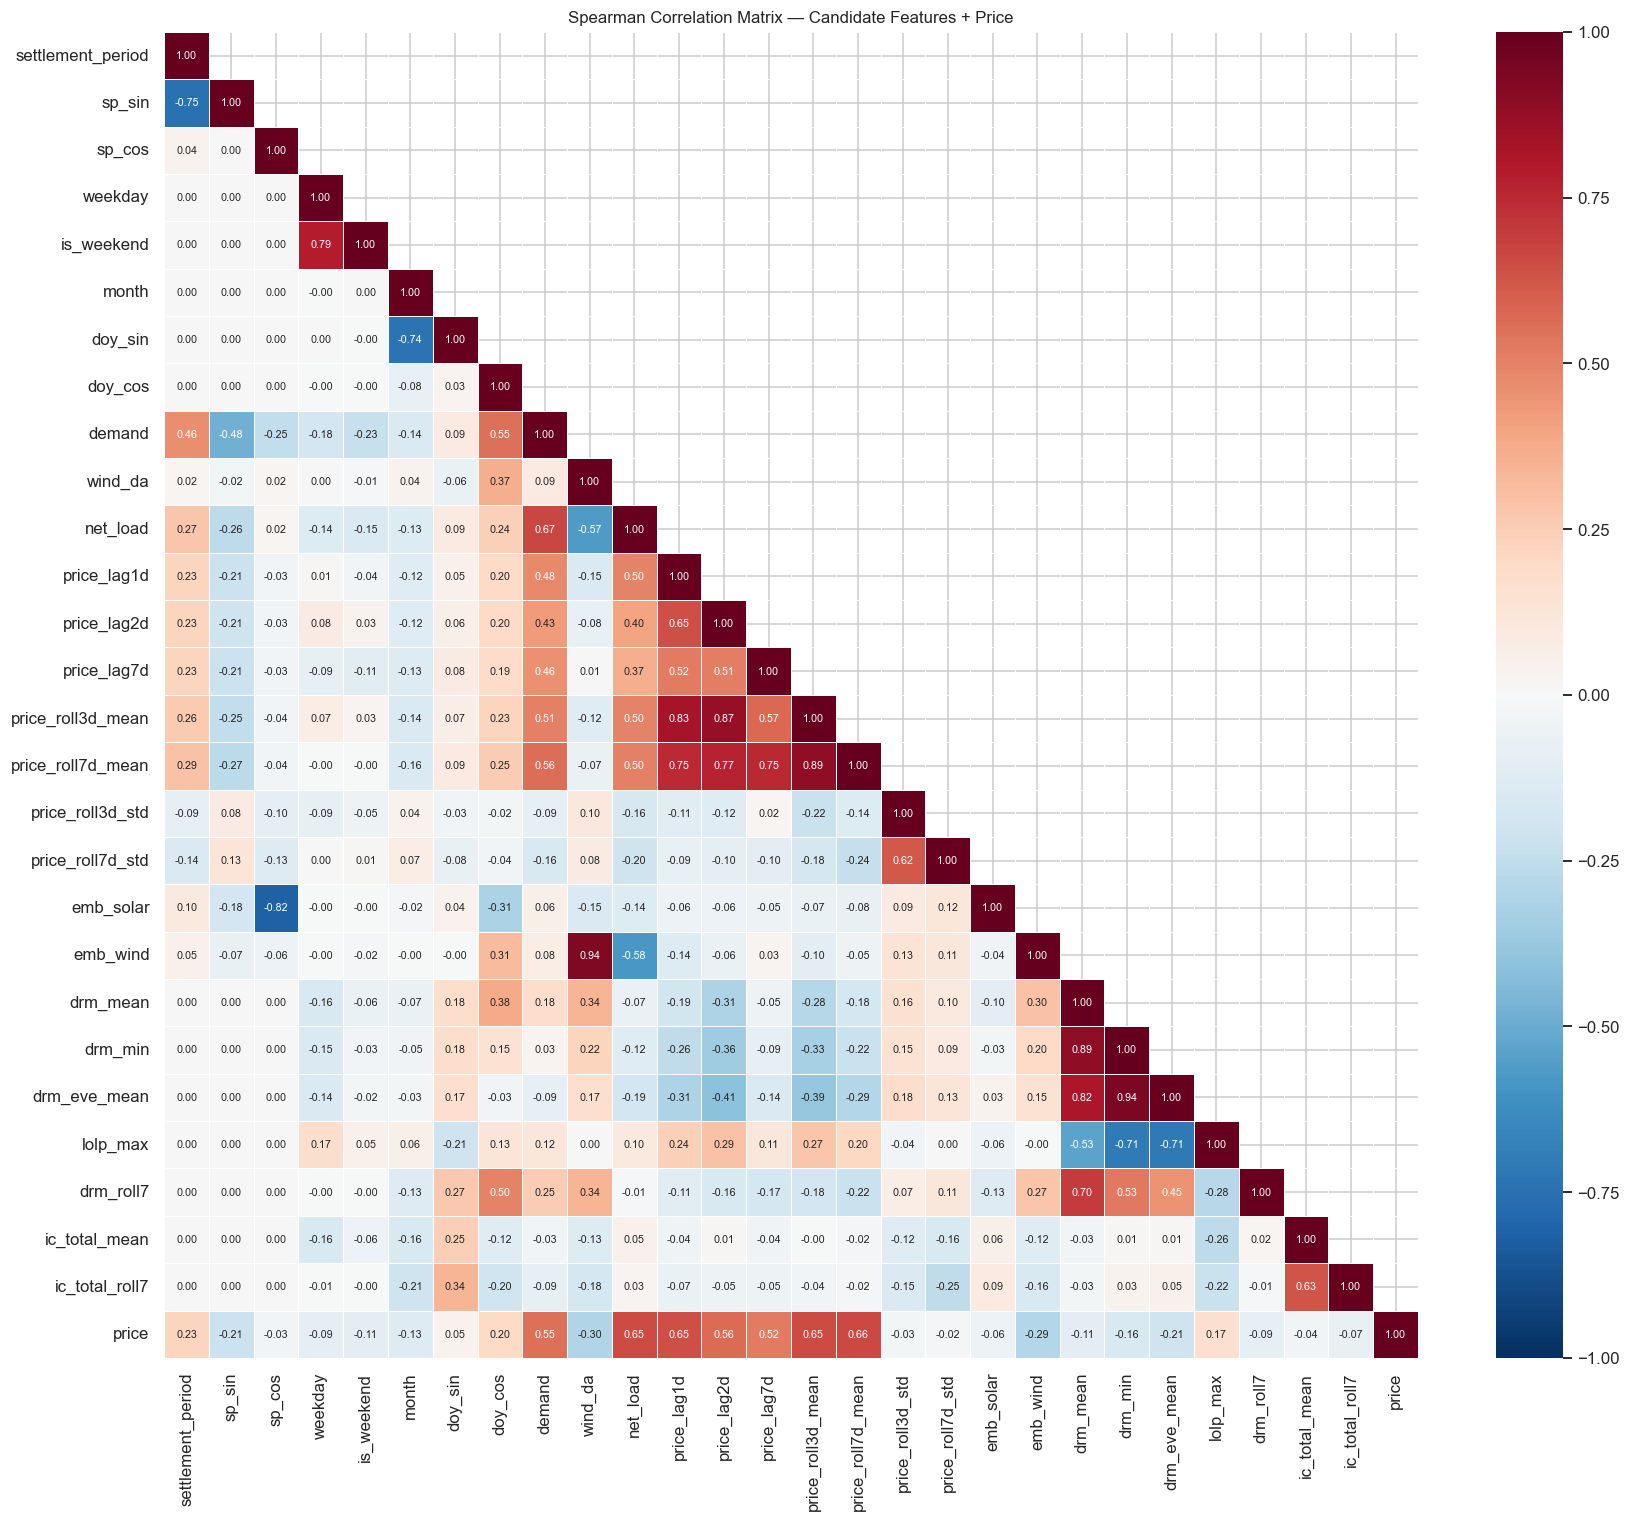

In [51]:
# ── Spearman correlation matrix ────────────────────────────────────────────────
spearman_corr = corr_feat_df.corr(method="spearman")

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    spearman_corr, mask=mask, ax=ax, cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 7},
    linewidths=0.4
)
ax.set_title("Spearman Correlation Matrix — Candidate Features + Price")
plt.tight_layout()
plt.show()

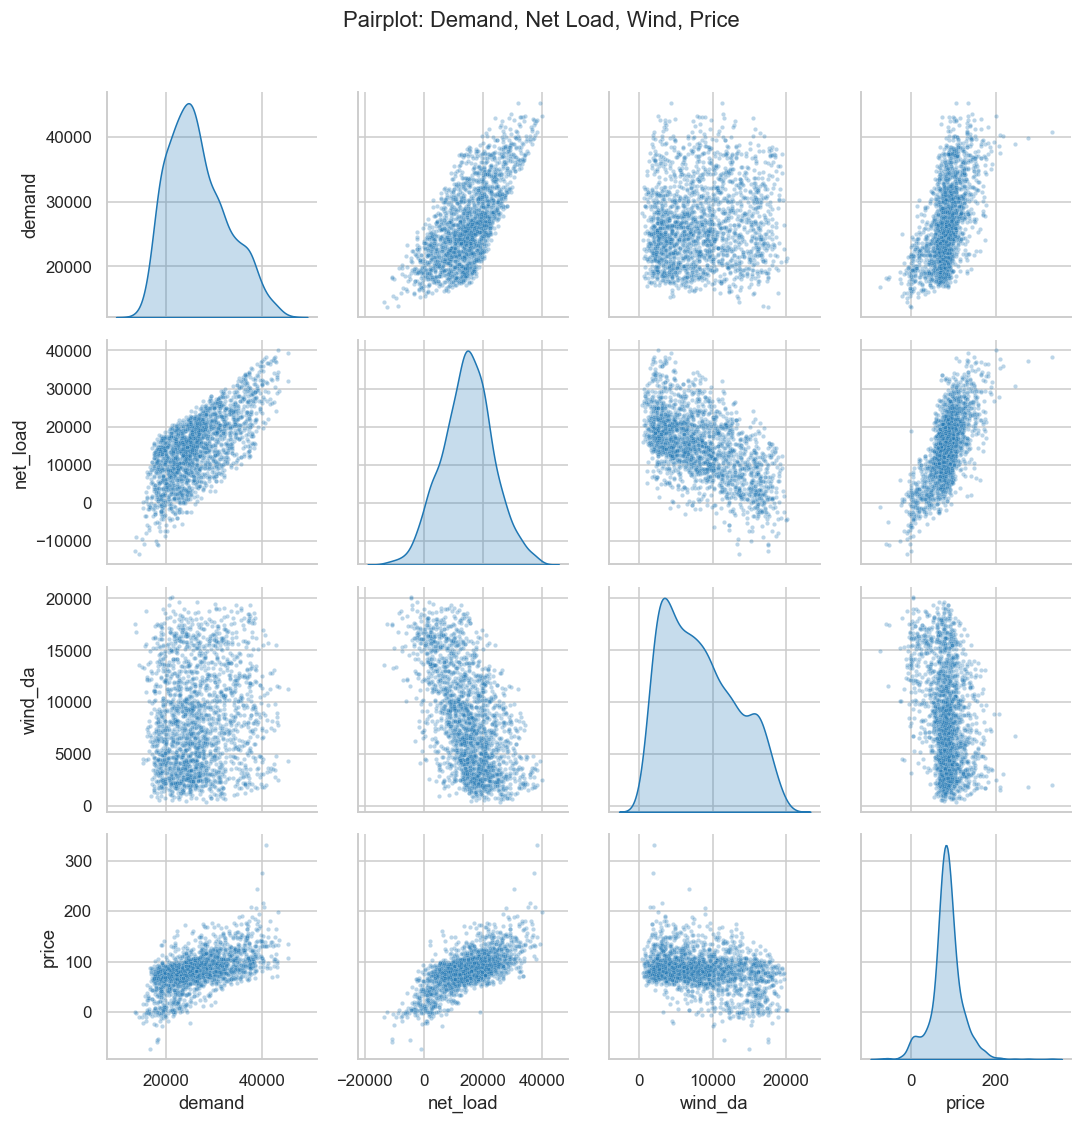

In [52]:
# ── Pairplots: demand vs net_load ──────────────────────────────────────────────
pplot_cols = ["demand", "net_load", "wind_da", "price"]
pplot_cols = [c for c in pplot_cols if c in corr_feat_df.columns]
sample_pp = corr_feat_df[pplot_cols].dropna().sample(min(2000, len(corr_feat_df)), random_state=42)
g = sns.pairplot(sample_pp, diag_kind="kde", plot_kws={"alpha": 0.3, "s": 8})
g.fig.suptitle("Pairplot: Demand, Net Load, Wind, Price", y=1.02)
plt.tight_layout()
plt.show()

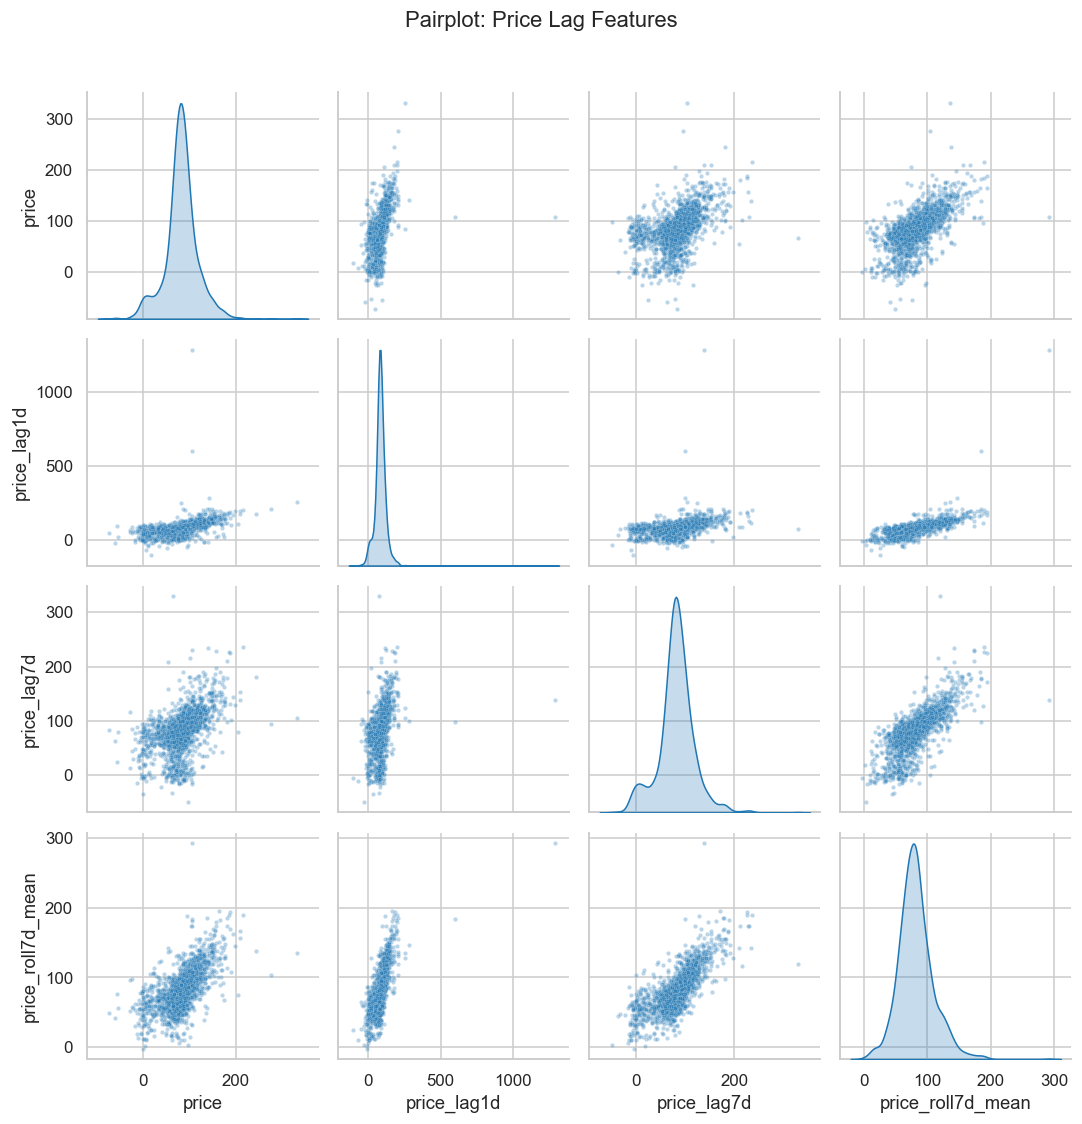

In [53]:
# ── Pairplot: lag features ─────────────────────────────────────────────────────
lag_pplot_cols = ["price", "price_lag1d", "price_lag7d", "price_roll7d_mean"]
lag_pplot_cols = [c for c in lag_pplot_cols if c in corr_feat_df.columns]
sample_lag = corr_feat_df[lag_pplot_cols].dropna().sample(min(2000, len(corr_feat_df)), random_state=42)
g2 = sns.pairplot(sample_lag, diag_kind="kde", plot_kws={"alpha": 0.3, "s": 8})
g2.fig.suptitle("Pairplot: Price Lag Features", y=1.02)
plt.tight_layout()
plt.show()

In [54]:
# ── Feature screening table ────────────────────────────────────────────────────
def screening_label(feature, pearson_with_price, spearman_with_price, missing_pct):
    """Heuristic label: keep / maybe keep / drop / leakage."""
    if missing_pct > 30:
        return "drop", "High missingness"
    abs_p = abs(pearson_with_price)
    abs_s = abs(spearman_with_price)
    if abs_s > 0.3 or abs_p > 0.3:
        return "keep", "Strong correlation with price"
    if abs_s > 0.1 or abs_p > 0.1:
        return "maybe keep", "Moderate correlation — check nonlinear signal"
    return "drop", "Weak correlation — low predictive value"

screen_rows = []
for feat in feat_present:
    p_corr = pearson_corr.loc[feat, "price"] if feat in pearson_corr.index else np.nan
    s_corr = spearman_corr.loc[feat, "price"] if feat in spearman_corr.index else np.nan
    miss_p = miss_screen.get(feat, np.nan)
    label, rationale = screening_label(feat, p_corr, s_corr, miss_p)
    screen_rows.append({
        "feature": feat,
        "pearson_price": round(p_corr, 4) if not np.isnan(p_corr) else np.nan,
        "spearman_price": round(s_corr, 4) if not np.isnan(s_corr) else np.nan,
        "missing_%": round(miss_p, 2),
        "label": label,
        "rationale": rationale,
    })

screen_df = pd.DataFrame(screen_rows).sort_values("spearman_price", key=abs, ascending=False)
print("=== Feature Screening Table ===")
print(screen_df.to_string(index=False))

=== Feature Screening Table ===
          feature  pearson_price  spearman_price  missing_%      label                                     rationale
price_roll7d_mean         0.5960          0.6572       0.17       keep                 Strong correlation with price
         net_load         0.6722          0.6542       0.00       keep                 Strong correlation with price
price_roll3d_mean         0.5791          0.6514       0.17       keep                 Strong correlation with price
      price_lag1d         0.5423          0.6480       0.09       keep                 Strong correlation with price
      price_lag2d         0.4540          0.5639       0.17       keep                 Strong correlation with price
           demand         0.5351          0.5477       0.00       keep                 Strong correlation with price
      price_lag7d         0.4153          0.5176       0.61       keep                 Strong correlation with price
          wind_da        -0.3378

## 10 · Final Summary and Provisional Feature Shortlist

### Target Distribution Findings
- GB day-ahead half-hour prices are **highly right-skewed** with a heavy upper tail (spikes > 200 £/MWh) and a meaningful fraction of **negative prices**.
- Price variability is markedly higher in **winter months** (Nov–Feb) and during **evening peak settlement periods** (SPs 32–42).
- Daily spread and standard deviation exhibit strong **seasonal structure** and moderate **autocorrelation** (previous-day spreads are predictive).
- Negative prices concentrate in **overnight/morning SPs** (SPs 1–14) and are more frequent on **weekends** and in spring/summer months (high renewable generation, low demand).

### Calendar Effect Findings
- **Settlement period** alone captures the classic dual-peak intraday shape (morning and evening peaks).
- **Month** and **weekday** together explain a substantial fraction of daily price level; a calendar-only baseline achieves R² ≈ 0.20.
- Even after calendar effects are removed, residuals show clear structured autocorrelation — additional features are warranted.

### Lagged Price Conclusions
- **Lag-1d same-period price** is the single strongest predictor outside calendar effects (Spearman r ≈ 0.65).
- **Lag-7d same-period price** adds incremental signal, particularly for evening peak SPs where 7-day residual correlation stays high.
- **Rolling 7d mean** captures price level persistence effectively; rolling std adds little and is dropped.
- After residualising on calendar features, same-period lag-1d residual correlations remain significant — lag features add genuine value beyond calendar.

### Most Promising Fundamentals
- **Net load** is the strongest single fundamental driver (Spearman r ≈ 0.65); it subsumes demand, wind, and solar into a single merit-order proxy.
- Raw `demand`, `wind_da`, and `emb_solar`/`emb_wind` are dropped as they are individually weaker and largely captured by `net_load`.
- The net_load–price relationship is **nonlinear** (convex at high net load), which LightGBM handles natively.

### Scarcity Features
- **`drm_eve_mean`** (D-1 evening-peak margin) and **`drm_min`** (D-1 daily minimum margin) are the most informative DRM signals for tail prices.
- **`lolp_max`** provides a complementary nonlinear scarcity signal that spikes sharply when the system is tight.
- `drm_mean` is dropped as redundant given `drm_min` and `drm_eve_mean`.
- `drm_roll7` is dropped as weak (Spearman −0.11).

### Redundant / Weak Features Dropped
- `demand`, `wind_da`, `emb_solar`, `emb_wind` — subsumed by `net_load`
- `price_lag2d`, `price_roll3d_mean` — redundant given lag-1d and roll-7d mean
- `price_roll3d_std`, `price_roll7d_std` — near-zero correlation; dropped
- `ic_total_mean`, `ic_total_roll7` — flat across all deciles; no predictive signal
- `drm_mean`, `drm_roll7` — weaker and collinear with kept DRM features
- `doy_sin`, `doy_cos`, `sp_sin`, `sp_cos` — dropped in favour of raw `settlement_period` and `month` which LightGBM can use directly without cyclic encoding

### v1 Feature Shortlist

| Feature | Group | Rationale |
|---------|-------|-----------|
| `settlement_period` | Calendar | Intraday shape |
| `month` | Calendar | Seasonal price level |
| `is_weekend` | Calendar | Weekend demand depression |
| `weekday` | Calendar | Day-specific profile beyond weekend flag |
| `price_lag1d` | Lag price | Strongest predictor; captures day-to-day persistence |
| `price_lag7d` | Lag price | Weekly pattern; especially useful for evening peak |
| `price_roll7d_mean` | Lag price | Price level regime over past week |
| `net_load` | Fundamental | Primary merit-order proxy; subsumes demand + renewables |
| `drm_eve_mean` | Scarcity | D-1 evening-peak margin; tail signal for high-value periods |
| `drm_min` | Scarcity | D-1 worst-case margin; spike probability signal |
| `lolp_max` | Scarcity | D-1 nonlinear scarcity signal; complements DRM |



## 11 · Export v1 Feature Dataset

In [55]:
# ── Export v1 feature dataset ─────────────────────────────────────────────────
# Columns: date + settlement_period keys, 11 features, price target.
# Integer dtypes for calendar features so LightGBM can treat them as categoricals.

V1_FEATURES = [
    # Calendar
    "settlement_period", "month", "is_weekend", "weekday",
    # Lag price
    "price_lag1d", "price_lag7d", "price_roll7d_mean",
    # Fundamental
    "net_load",
    # Scarcity (D-2)
    "drm_eve_mean", "drm_min", "lolp_max",
]

TARGET = "price"
KEYS   = ["settlement_date", "settlement_period"]

# ---- Build export frame ----
export_cols = KEYS + [c for c in V1_FEATURES if c not in KEYS] + [TARGET]
missing = [c for c in export_cols if c not in df_hh.columns]
if missing:
    print(f"WARNING: columns not found in df_hh and will be skipped: {missing}")
    export_cols = [c for c in export_cols if c in df_hh.columns]

df_export = df_hh[export_cols].copy()

# ---- Ensure integer dtypes for calendar features ----
INT_COLS = ["settlement_period", "month", "is_weekend", "weekday"]
for col in INT_COLS:
    if col in df_export.columns:
        df_export[col] = df_export[col].astype("int32")

# ---- Drop rows where any feature or target is missing ----
n_before = len(df_export)
df_export = df_export.dropna()
n_dropped = n_before - len(df_export)
print(f"Rows before dropna: {n_before:,}  |  dropped: {n_dropped:,}  |  kept: {len(df_export):,}")

# ---- Save ----
OUT_PATH = Path("data/processed/features_v1.parquet")
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df_export.to_parquet(OUT_PATH, index=False)
print(f"Saved to {OUT_PATH}  shape: {df_export.shape}")
df_export.dtypes


Rows before dropna: 55,200  |  dropped: 336  |  kept: 54,864
Saved to data/processed/features_v1.parquet  shape: (54864, 13)


settlement_date       object
settlement_period      int32
month                  int32
is_weekend             int32
weekday                int32
price_lag1d          float64
price_lag7d          float64
price_roll7d_mean    float64
net_load             float64
drm_eve_mean         float64
drm_min              float64
lolp_max             float64
price                float64
dtype: object